# High-Frequency Trading Anomaly Detection

This notebook documents the full project pipeline in one place:

 > - EDA key findings : We did a more extensive data analysis that we detailed in the report and in a seperate notebook. In this notebook, we only look at the six most important findings that motivated every downstream decision.
 > - Feature engineering: Drawing from the EDA, we built 37-features.
 > - Simple supervised models: We documented the initial path we explore using the models we saw in class including: Logistic Regression, Random Forest, SVM with synthetic anomaly injection, autoencoders...  
 > - Our model: From our initial trials and extended literature review, we built our model: A z-score, Isolation Forest & Dense Autoencoder ensemble.
 > - Final ensemble : grid-searched weighted combination.

## Table of Contents

**Setup & Data**
- Section 1 — Setup (imports, configuration)
- Section 2 — Load Data
  - 2.1 Data Cleaning

**Part 1 — Exploratory Data Analysis**
- 1. Univariate Distributions
  - 1.1 Descriptive statistics per split
  - 1.2 Categorical & temporal column summaries
  - 1.3 Top-5 most-common values per numeric column
  - 1.4 Histograms — linear (bulk) & symlog (full range)
- 2. Train vs. Val vs. Test Distributional Comparison
  - 2.1 Side-by-side summary statistics
  - 2.2 Kolmogorov–Smirnov tests on the full splits
- 3. Per-Symbol Heterogeneity
  - 3.1 Per-symbol event counts across splits
  - 3.2 Per-symbol mean / std on train, by feature
- 4. Joint Feature Structure
  - 4.1 Pearson and Spearman correlation matrices
  - 4.2 Mahalanobis distance distribution
- 5. Manipulation Pattern Fingerprints
  - 5.1 Pump-and-dump
  - 5.2 Layering
  - 5.3 Quote stuffing

**Part 2 — Feature Engineering**
- 6. Feature Engineering (37-feature set, burst features, per-symbol z-scores)
- 7. Scale Features (RobustScaler fit on the normal pool)

**Part 3 — Simple Models**
- 8. Setup — labeled dataset for supervised training (synthetic anomaly injection)
- 9. Model 1 — Logistic Regression
- 10. Model 2 — Random Forest
- 11. Model 3 — SVM (Linear)
- 12. Model 4 — Dense Autoencoder
- 13. Initial Results of Simple Models
- 14. Ensemble — RF + Autoencoder (supervised + unsupervised)

**Part 4 — Advanced Anomaly Detectors**
- 15. Detector — Isolation Forest
- 16. Ensemble — Isolation Forest + Autoencoder (two unsupervised models)
- 17. Detector — Z-Score
- 18. Final Ensemble — Z-Score + Isolation Forest + Autoencoder (three unsupervised models)
  - 18.1 Strategy A — Grid-searched weights
  - 18.2 Strategy B — EDA-justified weights


## Section 1 : Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
from scipy.stats import ks_2samp, chi2

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42) # Adding reproducibility

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.dpi'] = 90

TRAIN_PATH = 'train_data.csv'
VAL_PATH   = 'val_data.csv'
TEST_PATH  = 'test_data.csv'
OUTPUT_DIR = './'

NUMERIC_FEATURES = [
    'ReturnBid1', 'ReturnAsk1',
    'DerivativeReturnBid1', 'DerivativeReturnAsk1',
    'BidSize1', 'AskSize1',
    'TradeBidSize', 'TradeAskSize',
    'CancelledBidSize', 'CancelledAskSize',
    'TradeBidIndicator', 'TradeAskIndicator',
    'CancelledBidIndicator', 'CancelledAskIndicator',
]
numeric_features = NUMERIC_FEATURES  # alias used in EDA cells

print("Setup complete")

Setup complete


## Section 2 : Load Data

### 2.1 Data Cleaning

In [2]:
# Load all three splits
train = pd.read_csv(TRAIN_PATH)
val = pd.read_csv(VAL_PATH)
test = pd.read_csv(TEST_PATH)

print(f' train: {train.shape}  val: {val.shape}  test: {test.shape}')

 train: (1070022, 23)  val: (467939, 23)  test: (289101, 21)


In [3]:
train.head()

,Date,Time,MilliSeconds,TimeInMilliSecs,ExternalSymbol,OriginalSequenceNumber,ReturnBid1,ReturnAsk1,DerivativeReturnBid1,DerivativeReturnAsk1,BidSize1,AskSize1,TradeBidSize,TradeAskSize,CancelledBidSize,CancelledAskSize,TradeBidIndicator,TradeAskIndicator,CancelledBidIndicator,CancelledAskIndicator,ClusterNo,TARGET,ID
0,20120621.0-100,100112,816,"36,072,816.0000",INTC,48222841,-0.0016,0.0090,-0.0016,0.0076,-0.8417,-0.9749,-0.1155,-0.1190,-0.2310,-0.5288,-0.1969,-0.1660,-0.4678,-0.4227,NaN,0.0000,0
1,20120621.0-100,100113,969,"36,073,969.0000",INTC,48305744,-0.0016,0.0090,-0.0016,0.0076,-0.8410,-0.9667,-0.1155,-0.1190,-0.2310,-0.5288,-0.1969,-0.1660,-0.4716,-0.4227,NaN,0.0000,1
2,20120621.0-100,100113,986,"36,073,986.0000",INTC,48306207,-0.0016,0.0090,-0.0016,0.0076,-0.8387,-0.9586,-0.1155,-0.1190,-0.2752,-0.5288,-0.1969,-0.1660,-0.4716,-0.4227,NaN,0.0000,2
3,20120621.0-100,100114,699,"36,074,699.0000",INTC,48318967,-0.0016,0.0090,-0.0016,0.0076,-0.8369,-0.9504,-0.1155,-0.1190,-0.2752,-0.5288,-0.1969,-0.1660,-0.4716,-0.4227,NaN,0.0000,3
4,20120621.0-100,100115,826,"36,075,826.0000",INTC,48306207,-0.0016,0.0090,-0.0016,0.0076,-0.8347,-0.9422,-0.1155,-0.1190,-0.2872,-0.5288,-0.1969,-0.1660,-0.4692,-0.4227,NaN,0.0000,4


In [4]:
test.head()

,Date,Time,MilliSeconds,TimeInMilliSecs,ExternalSymbol,OriginalSequenceNumber,ReturnBid1,ReturnAsk1,DerivativeReturnBid1,DerivativeReturnAsk1,BidSize1,AskSize1,TradeBidSize,TradeAskSize,CancelledBidSize,CancelledAskSize,TradeBidIndicator,TradeAskIndicator,CancelledBidIndicator,CancelledAskIndicator,index
0,20120621-0,93000,5,"34,200,005.0000",AAPL,16113575,0.0019,0.3995,0.0004,0.5789,NaN,NaN,NaN,NaN,NaN,NaN,-0.2708,-0.2684,-0.2543,-0.2626,0
1,20120621-0,93000,26,"34,200,026.0000",AAPL,16120456,-9.3530,0.0177,-0.5902,0.0141,NaN,NaN,NaN,NaN,NaN,NaN,-0.2708,-0.2684,-0.2543,-0.2626,1
2,20120621-0,93000,26,"34,200,026.0000",AAPL,16120456-000001-000,9.3567,0.0177,12.4037,0.0141,NaN,NaN,NaN,NaN,NaN,NaN,-0.2708,-0.2684,-0.2543,-0.2626,2
3,20120621-0,93000,26,"34,200,026.0000",AAPL,16120456-000001-001,-9.3530,0.0177,-12.4029,0.0141,NaN,NaN,NaN,NaN,NaN,NaN,-0.2708,-0.2684,4.2231,-0.2626,3
4,20120621-0,93000,26,"34,200,026.0000",AAPL,16120456-000001-002,9.3567,0.0177,12.4037,0.0141,NaN,NaN,NaN,NaN,NaN,NaN,-0.2708,-0.2684,-0.2543,-0.2626,4


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070022 entries, 0 to 1070021
Data columns (total 23 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Date                    1070022 non-null  object 
 1   Time                    1070022 non-null  int64  
 2   MilliSeconds            1070022 non-null  int64  
 3   TimeInMilliSecs         1070022 non-null  float64
 4   ExternalSymbol          1070022 non-null  object 
 5   OriginalSequenceNumber  1070022 non-null  int64  
 6   ReturnBid1              1070022 non-null  float64
 7   ReturnAsk1              1070022 non-null  float64
 8   DerivativeReturnBid1    1070022 non-null  float64
 9   DerivativeReturnAsk1    1070022 non-null  float64
 10  BidSize1                1070022 non-null  float64
 11  AskSize1                1070022 non-null  float64
 12  TradeBidSize            1070022 non-null  float64
 13  TradeAskSize            1070022 non-null  float64
 14  Ca

From our inspection of the data, we see that ClusterNo shows up with 0 non-null entries across all rows -  it's completely empty so we drop the column all together.

In [6]:
# check for nulls
print("train:", train.isnull().sum().sum())
print("val:", val.isnull().sum().sum())
print("test:", test.isnull().sum().sum())

train: 1070022
val: 467939
test: 278


Train and val are clean. Test has 36 NaNs concentrated in the size columns so we'll fill those with 0 during feature engineering since 0 represents "no activity" for those columns.

In [7]:
print(train['ClusterNo'].isna().sum(), "/", len(train))
train.drop(columns=['ClusterNo'], inplace=True)
val.drop(columns=['ClusterNo'], inplace=True)

1070022 / 1070022


In [8]:
# test uses "index" instead of "ID" rename to match
print("train cols:", [c for c in train.columns if c in ['ID','index']])
print("test cols:", [c for c in test.columns  if c in ['ID','index']])

test = test.rename(columns={'index': 'ID'})


train cols: ['ID']
test cols: ['index']


The identifier column is called ID in train but index in test. Same column, different name so we rename it now so the submission format is consistent.

In [9]:
# OriginalSequenceNumber looks different in test — check
print(train['OriginalSequenceNumber'].dtype, train['OriginalSequenceNumber'].head(3).tolist())
print(test ['OriginalSequenceNumber'].dtype, test ['OriginalSequenceNumber'].head(3).tolist())


int64 [48222841, 48305744, 48306207]
object ['16113575', '16120456', '16120456-000001-000']


In [10]:
# both train and val are 100% normal - we can combine them as our normal pool
print(train['TARGET'].value_counts())
print(val['TARGET'].value_counts())

normal = pd.concat([train, val], ignore_index=True)
print("normal pool:", len(normal))


TARGET
0.0000    1070022
Name: count, dtype: int64
TARGET
0.0000    467939
Name: count, dtype: int64


normal pool: 1537961


In [11]:
# Both are confirmed 100% normal (TARGET=0 throughout train and val)
print('TARGET distribution:')
for name, df in [('train', train), ('val', val)]:
    if 'TARGET' in df.columns:
        print(f'    {name}: {df["TARGET"].value_counts().to_dict()}  (all 0 = all normal)')
    else:
        print(f'    {name}: TARGET column absent')

# normal = pd.concat([train, val], ignore_index=True)

print(f'Normal pool: {len(normal):,} rows') # used for fitting
print(f'Test: {len(test):,} rows') # used for scoring only
print(f'Symbols: {sorted(test["ExternalSymbol"].unique())}')


TARGET distribution:
    train: {0.0: 1070022}  (all 0 = all normal)
    val: {0.0: 467939}  (all 0 = all normal)
Normal pool: 1,537,961 rows
Test: 289,101 rows
Symbols: ['AAPL', 'AMZN', 'GOOG', 'INTC', 'MSFT']


Our inspection of the data has identified four cleanup actions that should be applied before any modelling. First, ClusterNo should be dropped because it is 100% NaN in both the training and validation sets and is absent from the test set. Second, the index column in the test set should be renamed to ID, since it plays the same role as the ID column in the training and validation sets but uses a different name. Third, OriginalSequenceNumber should be made consistent across datasets because it is stored as an int64 in train and validation, but as an object in the test set, with values such as 16120456-000001-000; to fix this, we extract a uniform base_seq column from the prefix (This function is implemented inside add_burst_features(df) in cell 61). Finally, because the test set contains 36 missing values in the size columns and one missing value in the returns column, numeric features should be filled with 0 (implemented in the function engineer_features() later), which represents the post-standardization mode for “no event.” We also build the normal pool by combining the training and validation sets, since both are 100% normal and v2 uses them jointly for fitting.

# Part 1 : Exploratory Data Analysis

### 1.1 Descriptive statistics per split

To understand the data better before moving into modelling, we first perform a basic exploratory analysis on each dataset split. We start with standard descriptive statistics for the numeric columns, then look more closely at the categorical, temporal, identifier, and metadata columns that need a separate interpretation.


For every numeric column we report count, mean, std, min, the four quartiles, and max. The count row also surfaces missing values (compare to the dataset's row count).

In [12]:
for split_name, df in [('train', train), ('val', val), ('test', test)]:
    print(f'\n{split_name}  shape={df.shape}')
    display(df.describe(include=[np.number]).T)


train  shape=(1070022, 22)


,count,mean,std,min,25%,50%,75%,max
Time,"1,070,022.0000","127,592.8267","20,964.9834","93,121.0000","110,344.0000","130,756.0000","150,041.0000","160,349.0000"
MilliSeconds,"1,070,022.0000",498.7266,289.8963,0.0000,246.0000,499.0000,751.0000,999.0000
TimeInMilliSecs,"1,070,022.0000","46,719,097.7666","7,595,271.5202","34,281,175.0000","39,824,217.0000","47,276,115.0000","54,041,967.7500","57,829,051.0000"
OriginalSequenceNumber,"1,070,022.0000","164,084,227.7531","78,868,932.6205","30,890.0000","95,164,412.7500","172,342,921.0000","234,090,489.7500","287,173,095.0000"
ReturnBid1,"1,070,022.0000",0.0023,0.9173,-25.8411,-0.0019,-0.0002,0.0010,25.8430
ReturnAsk1,"1,070,022.0000",0.0177,0.3626,-9.0401,0.0090,0.0178,0.0235,9.0871
DerivativeReturnBid1,"1,070,022.0000",0.0078,0.9122,-36.2254,-0.0019,-0.0016,-0.0006,36.2134
DerivativeReturnAsk1,"1,070,022.0000",0.0141,0.3685,-10.1383,0.0076,0.0135,0.0263,7.8914
BidSize1,"1,070,022.0000",0.0397,0.9899,-1.2477,-0.3486,-0.1371,0.0889,29.2526
AskSize1,"1,070,022.0000",0.0260,1.0738,-1.3355,-0.4619,-0.1911,0.2118,52.4182



val  shape=(467939, 22)


,count,mean,std,min,25%,50%,75%,max
Time,"467,939.0000","128,071.9615","17,210.1073","93,059.0000","120,007.0000","125,034.0000","142,451.0000","160,000.0000"
MilliSeconds,"467,939.0000",499.6516,290.4528,0.0000,253.0000,501.0000,752.0000,999.0000
TimeInMilliSecs,"467,939.0000","46,834,636.2592","6,138,296.1989","34,259,280.0000","43,207,086.0000","46,234,153.0000","51,891,074.0000","57,600,996.0000"
OriginalSequenceNumber,"467,939.0000","165,793,145.9217","62,897,087.4704","857,798.0000","133,231,156.0000","165,642,738.0000","214,741,961.0000","282,630,080.0000"
ReturnBid1,"467,939.0000",0.0046,0.8311,-16.2670,-0.0019,-0.0016,0.0010,16.2638
ReturnAsk1,"467,939.0000",0.0185,0.3292,-5.3333,0.0090,0.0178,0.0235,5.3513
DerivativeReturnBid1,"467,939.0000",0.0104,0.8286,-16.7463,-0.0019,-0.0016,-0.0006,16.7431
DerivativeReturnAsk1,"467,939.0000",0.0142,0.3363,-6.0549,0.0076,0.0135,0.0263,6.0701
BidSize1,"467,939.0000",-0.0456,0.6638,-1.2431,-0.3501,-0.1449,0.0351,8.9252
AskSize1,"467,939.0000",-0.0642,0.6554,-1.3357,-0.4116,-0.1860,0.1649,17.0321



test  shape=(289101, 21)


,count,mean,std,min,25%,50%,75%,max
Time,"289,101.0000","119,263.4897","24,035.5318","93,000.0000","94,625.0000","113,455.0000","145,008.0000","160,350.0000"
MilliSeconds,"289,101.0000",495.4817,288.5523,0.0000,249.0000,490.0000,748.0000,999.0000
TimeInMilliSecs,"289,101.0000","43,688,574.2466","8,665,117.0675","34,200,005.0000","35,185,570.0000","41,695,820.0000","53,408,434.0000","57,830,619.0000"
ReturnBid1,"289,099.0000",0.0033,17.9836,-300.4934,-0.0017,-0.0017,-0.0005,300.4901
ReturnAsk1,"289,099.0000",0.0141,6.0676,-97.2636,0.0090,0.0090,0.0177,97.2817
DerivativeReturnBid1,"289,099.0000",-0.0014,3.1541,-58.1239,-0.0018,-0.0016,-0.0016,36.2413
DerivativeReturnAsk1,"289,099.0000",-0.0308,2.1174,-110.2013,0.0075,0.0078,0.0141,20.1132
BidSize1,"289,056.0000",-0.0707,1.1635,-1.2490,-0.6427,-0.1852,0.1150,30.5041
AskSize1,"289,056.0000",-0.0020,1.2625,-1.3336,-0.7072,-0.2097,0.3552,52.5355
TradeBidSize,"289,056.0000",-0.0108,1.4174,-0.2378,-0.1932,-0.1032,-0.0950,158.9021


### 1.2 Categorical & temporal column summaries

After reviewing the numeric features, we further inspect the columns that are not regular numeric modelling features to understand what they represent and whether they can be used in our modeling later on. 
Columns that aren't standard numeric features get their own summary:

> - ExternalSymbol is treated as a categorical column, so we look at its value counts to see how often each symbol appears. 
> - Date is stored as a string and includes a session marker, so we check how many unique values it has and look at a few examples. 
> - For the timestamp-related columns, including Time, MilliSeconds, and TimeInMilliSecs, we check their data type, range, and number of unique values.
> -  We also review the identifier columns, such as OriginalSequenceNumber, ID, and index, because they help track observations but are not direct modelling features. 
> - Finally, we summarize special metadata columns like ClusterNo and TARGET, which appear only in the training and validation sets.

In [13]:
def cat_temporal_summary(df, name):
    print(f'\n {name}  shape={df.shape} ')

    if 'ExternalSymbol' in df.columns:
        sym_vc = df['ExternalSymbol'].value_counts(dropna=False)
        print(f'\n  ExternalSymbol - {df["ExternalSymbol"].nunique()} unique:')
        for s, c in sym_vc.items():
            print(f'   {str(s):8s}  count={c:>10,}  pct={c/len(df)*100:>5.2f}%')

    if 'Date' in df.columns:
        d_vc = df['Date'].value_counts(dropna=False)
        print(f'\n  Date : {df["Date"].nunique()} unique values | examples: {list(d_vc.index[:5])}')

    print()
    for col in ['Time', 'MilliSeconds', 'TimeInMilliSecs']:
        if col in df.columns:
            s = df[col]
            print(f'  {col:18s} dtype={str(s.dtype):8s} min={s.min():>15} max={s.max():>15} n_unique={s.nunique():>10,}')

    print()
    for col in ['OriginalSequenceNumber', 'ID', 'index']:
        if col in df.columns:
            s = df[col]
            print(f'  {col:24s} dtype={str(s.dtype):8s} n_unique={s.nunique():>10,} sample={s.iloc[0]!r}')

    if 'ClusterNo' in df.columns:
        s = df['ClusterNo']
        print(f'\n  ClusterNo: dtype={s.dtype}, nulls={s.isnull().sum():,}/{len(df):,}, non_null_unique={s.dropna().nunique()}')

    if 'TARGET' in df.columns:
        print(f'  TARGET: unique values = {sorted(df["TARGET"].unique())}, dtype = {df["TARGET"].dtype}')

cat_temporal_summary(train, 'train')
cat_temporal_summary(val,   'val')
cat_temporal_summary(test,  'test')


 train  shape=(1070022, 22) 

  ExternalSymbol - 5 unique:
   INTC      count=   226,109  pct=21.13%
   MSFT      count=   224,561  pct=20.99%
   GOOG      count=   215,865  pct=20.17%
   AMZN      count=   212,912  pct=19.90%
   AAPL      count=   190,575  pct=17.81%

  Date : 777 unique values | examples: ['20120621.0-98', '20120621.0-376', '20120621.0-128', '20120621.0-150', '20120621.0-360']

  Time               dtype=int64    min=          93121 max=         160349 n_unique=    20,832
  MilliSeconds       dtype=int64    min=              0 max=            999 n_unique=     1,000
  TimeInMilliSecs    dtype=float64  min=     34281175.0 max=     57829051.0 n_unique=   216,550

  OriginalSequenceNumber   dtype=int64    n_unique=   322,336 sample=np.int64(48222841)
  ID                       dtype=int64    n_unique= 1,070,022 sample=np.int64(0)
  TARGET: unique values = [np.float64(0.0)], dtype = float64

 val  shape=(467939, 22) 

  ExternalSymbol - 5 unique:
   MSFT      count=   1

### 1.3 Top-5 most-common values per numeric column

We notice that several numeric features have repeated values that appear very often. This is important to inspect because a feature can look fine in the descriptive statistics, but still be dominated by one specific value. Regular histograms may also hide this pattern, so we check the most common values directly.

The first table shows the top five most common values for each numeric feature in the training set, along with their counts and percentages. The second table ranks the columns by the percentage of rows held by their most common value, so the strongest mass-spike columns appear first.

In [14]:
numeric_features = [
    'ReturnBid1','ReturnAsk1','DerivativeReturnBid1','DerivativeReturnAsk1',
    'BidSize1','AskSize1','TradeBidSize','TradeAskSize',
    'CancelledBidSize','CancelledAskSize',
    'TradeBidIndicator','TradeAskIndicator','CancelledBidIndicator','CancelledAskIndicator',
]

rows = []
for col in numeric_features:
    s = train[col]
    vc= s.value_counts(dropna=False).head(5)
    total = len(s)
    for rank, (value, cnt) in enumerate(vc.items(), start=1):
        rows.append({
            'column': col,
            'rank': rank,
            'value':round(value, 6) if pd.notnull(value) else value,
            'count':cnt,
            'pct':round(cnt/total*100, 2),
        })

mode_table = pd.DataFrame(rows)
print(' Top-5 most-common values per numeric column (train')
display(mode_table)

print('\n Rank 1 mode share by column (mass-spike severity)')
display(
    mode_table[mode_table['rank']==1]
    .sort_values('pct', ascending=False)[['column','value','count','pct']]
    .reset_index(drop=True)
)

 Top-5 most-common values per numeric column (train


,column,rank,value,count,pct
0,ReturnBid1,1,-0.0016,225310,21.0600
1,ReturnBid1,2,-0.0019,223535,20.8900
2,ReturnBid1,3,-0.0002,166617,15.5700
3,ReturnBid1,4,0.0010,160800,15.0300
4,ReturnBid1,5,0.0013,131976,12.3300
...,...,...,...,...,...
65,CancelledAskIndicator,1,-0.2700,182709,17.0800
66,CancelledAskIndicator,2,-0.4227,180069,16.8300
67,CancelledAskIndicator,3,-0.2972,177008,16.5400
68,CancelledAskIndicator,4,-0.4795,174033,16.2600



 Rank 1 mode share by column (mass-spike severity)


,column,value,count,pct
0,ReturnBid1,-0.0016,225310,21.0600
1,ReturnAsk1,0.0090,225360,21.0600
2,DerivativeReturnBid1,-0.0016,225310,21.0600
3,DerivativeReturnAsk1,0.0076,225360,21.0600
4,TradeAskSize,-0.1190,219193,20.4800
5,TradeAskIndicator,-0.1660,219193,20.4800
6,TradeBidSize,-0.1155,216894,20.2700
7,TradeBidIndicator,-0.1969,216894,20.2700
8,CancelledBidIndicator,-0.2984,188802,17.6400
9,CancelledAskIndicator,-0.2700,182709,17.0800


### 1.4 Histograms : linear (bulk) & symlog (full range)

To better understand the numeric distributions, we plot two histogram views for each feature in the training set. The linear histogram focuses on the main part of the distribution, while the symlog view shows the full range, including extreme tails and repeated-value spikes that may be hidden in a regular plot.

We group the features into returns and derivatives, size-related features, and indicator features so the plots are easier to read.

In [15]:
def plot_feature_hist(s, ax_lin, ax_log, name):
    s = s.dropna()
    p1, p99 = s.quantile([0.01, 0.99])

    ax_lin.hist(s, bins=80, range=(p1, p99), color='steelblue', edgecolor='none')
    ax_lin.axvline(s.mean(),   color='red',    linestyle='--', linewidth=1, label=f'mean={s.mean():.4f}')
    ax_lin.axvline(s.median(), color='orange', linestyle='--', linewidth=1, label=f'median={s.median():.4f}')
    ax_lin.set_title(f'{name} : linear, range [p1, p99]', fontsize=9)
    ax_lin.legend(fontsize=8, loc='upper right')

    linthresh = max(s.std() / 4, 1e-6)
    ax_log.hist(s, bins=80, color='coral', edgecolor='none')
    ax_log.set_xscale('symlog', linthresh=linthresh)
    ax_log.set_yscale('log')
    ax_log.set_title(f'{name} :  symlog x (linthresh={linthresh:.3g}), log y, full range [{s.min():.2f}, {s.max():.2f}]', fontsize=9)

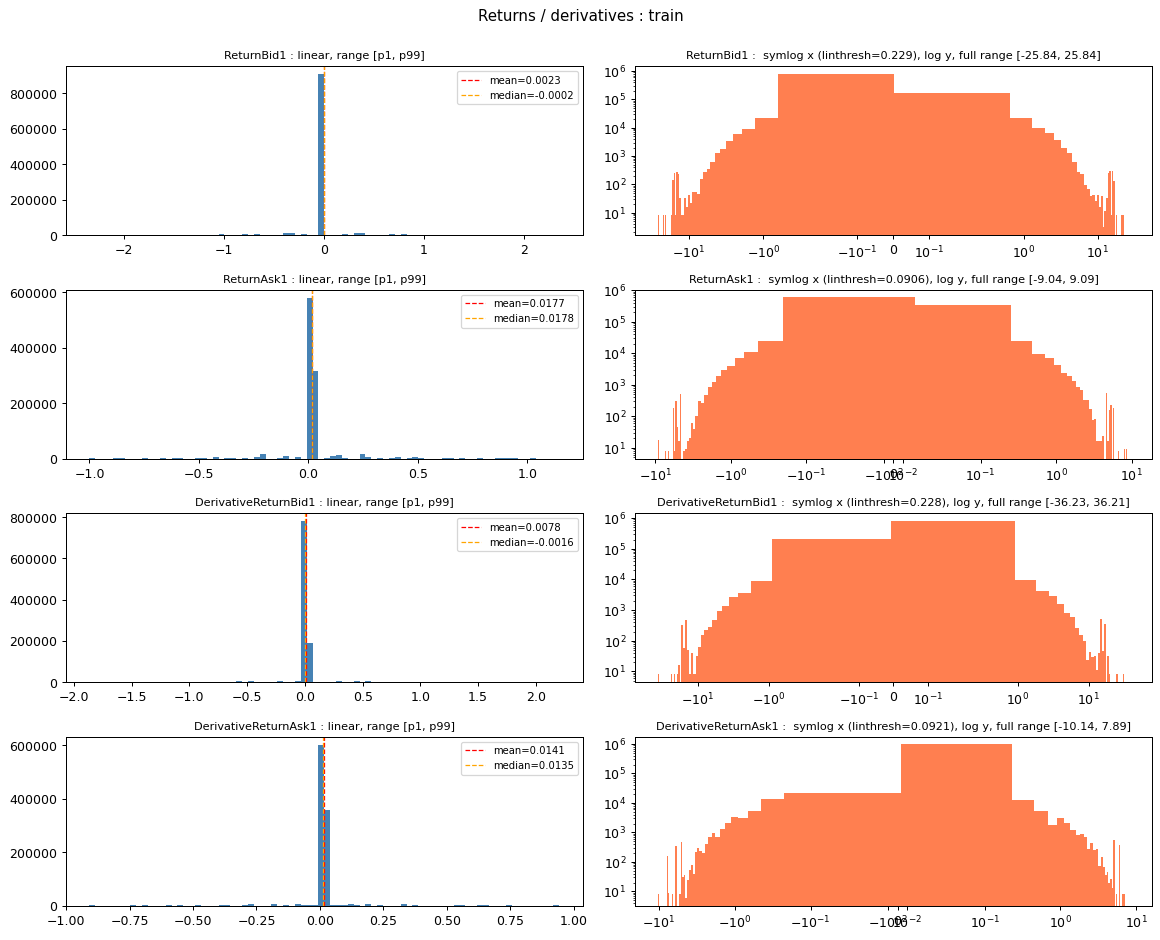

In [16]:
returns_cols = ['ReturnBid1','ReturnAsk1','DerivativeReturnBid1','DerivativeReturnAsk1']
fig, axes = plt.subplots(len(returns_cols), 2, figsize=(13, 2.6*len(returns_cols)))
fig.suptitle('Returns / derivatives : train', y=1.00, fontsize=12)
for i, col in enumerate(returns_cols):
    plot_feature_hist(train[col], axes[i,0], axes[i,1], col)
plt.tight_layout()
plt.show()


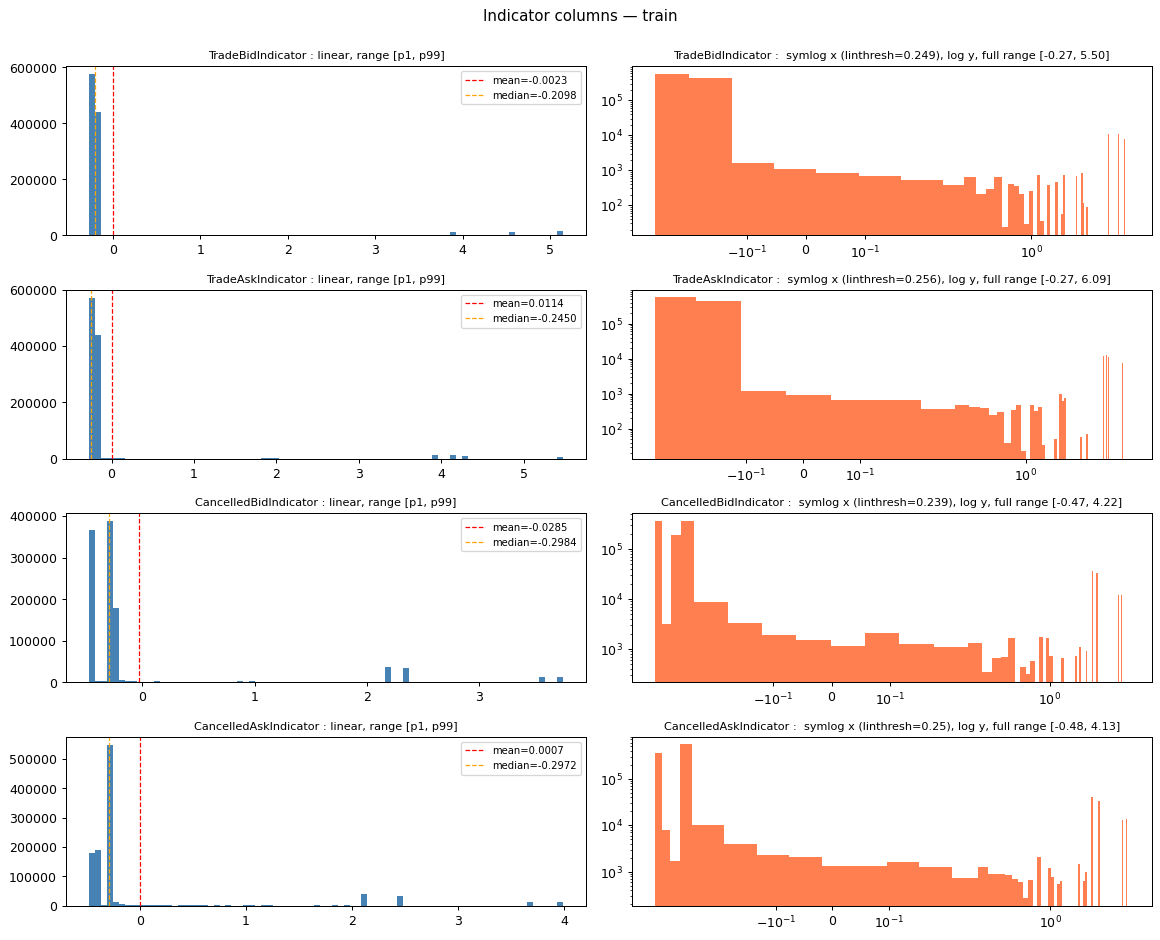

In [17]:
indicators_cols = ['TradeBidIndicator','TradeAskIndicator','CancelledBidIndicator','CancelledAskIndicator']
fig, axes = plt.subplots(len(indicators_cols), 2, figsize=(13, 2.6*len(indicators_cols)))
fig.suptitle('Indicator columns — train', y=1.00, fontsize=12)
for i, col in enumerate(indicators_cols):
    plot_feature_hist(train[col], axes[i,0], axes[i,1], col)
plt.tight_layout()
plt.show()

The histogram views confirm that most features are highly concentrated around a small central range, with long tails on both sides. For the return and derivative columns, the distributions are mostly centered near zero, while the symlog plots show that there are still extreme values far away from the center. This supports the idea that the data has already been scaled, but still contains heavy tails.

For the indicator columns, the distributions are much more uneven. Most observations are concentrated around one or two repeated negative values, while a smaller number of observations extend far into the positive range. This suggests that many rows represent “no event” or low-activity cases, while the positive tail captures rarer trading or cancellation events. The symlog plots are useful here because they make these rare but large values visible.

## 2. Train vs. Val vs. Test Distributional Comparison
After understanding each split separately, we compare the train, validation, and test distributions to see whether the data behaves consistently across splits.

This step is important because the train and validation sets are both 100% normal, so they should look very similar. If train and validation are very different, that would suggest a split issue, such as sampling bias, leakage, or temporal shift. The test set, however, contains both normal and anomalous events, so we expect it to differ from train and validation. The challenge is to understand whether those differences come from the anomalies we want to detect, or from unrelated drift such as a different symbol mix or time period.

To make this comparison clearer, we structure the section in four parts. First, we compare side-by-side summary statistics such as the mean, standard deviation, and median for each feature across the three splits. Then, we plot overlaid density histograms to visually compare train, validation, and test distributions. After that, we run two-sample Kolmogorov-Smirnov tests on the full splits. Finally, we repeat the KS tests on the common subset of symbols and dates that appear in all three splits, so that differences caused by unmatched symbols or dates do not get mistaken for real distributional drift.

For the KS test, we focus mainly on the D statistic instead of the p-value.if D < 0.02, then the two distributions are almost identical. If D is between 0.02 and 0.10, then the difference is small. If D is between 0.10 and 0.20, then the difference is moderate and worth paying attention to. If D > 0.20, then there is strong distributional drift between the two splits.


### 2.1 Side-by-side summary statistics

For each numeric feature, we line up mean, std, and p50 (median) across the three splits. The differences from train (Δ_val and Δ_test for the mean) are added so drift jumps out visually. The table is sorted by |Δ_test| in mean, so the columns most different in test rise to the top.

In [18]:
def split_compare_table(features):
    rows = []
    for col in features:
        row = {'feature': col}
        for label, df in [('train', train), ('val', val), ('test', test)]:
            if col in df.columns:
                s = df[col].dropna()
                row[f'{label}_mean'] = s.mean()
                row[f'{label}_std']  = s.std()
                row[f'{label}_p50']  = s.median()
            else:
                row[f'{label}_mean'] = np.nan
                row[f'{label}_std']  = np.nan
                row[f'{label}_p50']  = np.nan
        row['delta_mean_val']  = row['val_mean']  - row['train_mean']
        row['delta_mean_test'] = row['test_mean'] - row['train_mean']
        rows.append(row)
    out = pd.DataFrame(rows).set_index('feature')
    return out

cmp_table = split_compare_table(numeric_features)
cmp_table_sorted = cmp_table.reindex(cmp_table['delta_mean_test'].abs().sort_values(ascending=False).index)

print('Per-feature mean / std / p50 across splits, sorted by |Δ_test mean|')
display(cmp_table_sorted[['train_mean','val_mean','test_mean','delta_mean_val','delta_mean_test','train_std','val_std','test_std','train_p50','val_p50','test_p50']])

Per-feature mean / std / p50 across splits, sorted by |Δ_test mean|


,train_mean,val_mean,test_mean,delta_mean_val,delta_mean_test,train_std,val_std,test_std,train_p50,val_p50,test_p50
feature,,,,,,,,,,,
TradeAskSize,0.0047,-0.0333,0.2907,-0.0380,0.2860,0.9836,0.8535,7.0411,-0.2150,-0.2150,-0.1146
CancelledBidSize,-0.0304,-0.0234,0.1474,0.0070,0.1778,0.8562,0.7161,2.4756,-0.2366,-0.1832,-0.2827
CancelledBidIndicator,-0.0285,0.0097,0.1063,0.0382,0.1348,0.9563,1.0149,1.1474,-0.2984,-0.2984,-0.4352
BidSize1,0.0397,-0.0456,-0.0707,-0.0853,-0.1104,0.9899,0.6638,1.1635,-0.1371,-0.1449,-0.1852
CancelledAskSize,0.0014,-0.0058,-0.0795,-0.0073,-0.0810,0.9950,0.8967,1.0242,-0.2918,-0.2905,-0.4696
CancelledAskIndicator,0.0007,-0.0039,0.0594,-0.0046,0.0587,1.0016,0.9955,1.1013,-0.2972,-0.2972,-0.4227
TradeAskIndicator,0.0114,-0.0290,-0.0398,-0.0404,-0.0512,1.0227,0.9396,0.9031,-0.2450,-0.2450,-0.1842
DerivativeReturnAsk1,0.0141,0.0142,-0.0308,0.0001,-0.0449,0.3685,0.3363,2.1174,0.0135,0.0135,0.0078
AskSize1,0.0260,-0.0642,-0.0020,-0.0902,-0.0280,1.0738,0.6554,1.2625,-0.1911,-0.1860,-0.2097


### 2.3 Kolmogorov–Smirnov tests on the full splits
We now apply the K-S test to each numeric feature to quantify the distributional differences seen in the plots. The table reports D for train <-> val and train <-> test, then sorts the features by D_train_vs_test in descending order so the most divergent columns appear first.

In [19]:
from scipy.stats import ks_2samp

def ks_table(features, df_a, df_b, df_c, label_a='train', label_b='val', label_c='test'):
    rows = []
    for col in features:
        s_a = df_a[col].dropna().to_numpy() if col in df_a.columns else np.array([])
        s_b = df_b[col].dropna().to_numpy() if col in df_b.columns else np.array([])
        s_c = df_c[col].dropna().to_numpy() if col in df_c.columns else np.array([])
        D_ab, _ = (ks_2samp(s_a, s_b) if len(s_a) and len(s_b) else (np.nan, np.nan))
        D_ac, _ = (ks_2samp(s_a, s_c) if len(s_a) and len(s_c) else (np.nan, np.nan))
        rows.append({'feature': col, f'D_{label_a}_vs_{label_b}': D_ab, f'D_{label_a}_vs_{label_c}': D_ac,})
    return pd.DataFrame(rows).set_index('feature')

ks_full = ks_table(numeric_features, train, val, test)
ks_full_sorted = ks_full.sort_values('D_train_vs_test', ascending=False)

print('K–S two-sample test, full splits, sorted by D_train_vs_test')
display(ks_full_sorted.round({'D_train_vs_val': 4, 'D_train_vs_test': 4}))

K–S two-sample test, full splits, sorted by D_train_vs_test


,D_train_vs_val,D_train_vs_test
feature,,
TradeBidSize,0.0134,0.6463
DerivativeReturnAsk1,0.0125,0.4580
TradeBidIndicator,0.0135,0.4512
ReturnBid1,0.0152,0.4490
TradeAskSize,0.0140,0.4447
ReturnAsk1,0.0159,0.4414
CancelledBidIndicator,0.0136,0.3748
TradeAskIndicator,0.0195,0.3283
DerivativeReturnBid1,0.0114,0.2920


### Observations from Section 2

The main takeaway is that train and validation are very similar, while test is clearly different. The small train-validation KS values suggest that the validation split is healthy and can be used as a reliable normal reference.

The main source of train-test mismatch seems to be the date structure. Test only contains observations from 2012-06-21, while train and validation cover multiple dates. This means part of the train-test difference may come from the date structure rather than from anomalies alone. However, train already has a large share of rows from 2012-06-21, so restricting training to that date is a reasonable way to make the training distribution closer to the test distribution.

Feature drift is uneven. TradeBidSize has the largest difference with D = 0.6463, and several return, derivative, trade, and cancellation features also show strong drift. Restricting to the common date reduces some differences, but TradeBidSize remains highly different, suggesting it may carry real anomaly-related signal.

For modelling, this means that training on the 2012-06-21 subset may better match the test distribution and reduce unrelated date-driven drift

## 3. Per-Symbol Heterogeneity

Next, we compare the five symbols to see whether they follow similar or different distributions. This matters because each stock can have different price levels, depths, and event patterns, so a normal pattern for one symbol may look unusual for another.

We first check event counts per symbol in each split, then compare per-symbol means and standard deviations for numeric features in train. Finally, we use density overlays to visually compare the feature distributions by symbol.

One limitation is that train covers multiple dates, so these results may mix symbol effects with date effects. Section 4 looks at dates separately.


### 3.1 Per-symbol event counts across splits

In [20]:
cnt_tbl = pd.DataFrame({'train': train['ExternalSymbol'].value_counts(), 'val':   val  ['ExternalSymbol'].value_counts(),'test':  test ['ExternalSymbol'].value_counts(),}).fillna(0).astype(int).sort_index()

for col in ['train','val','test']:
    cnt_tbl[f'{col}_pct'] = (cnt_tbl[col] / cnt_tbl[col].sum() * 100).round(2)

print('Event counts and within-split share by ExternalSymbol')
display(cnt_tbl[['train','train_pct','val','val_pct','test','test_pct']])

Event counts and within-split share by ExternalSymbol


,train,train_pct,val,val_pct,test,test_pct
ExternalSymbol,,,,,,
AAPL,190575,17.8100,83980,17.9500,35176,12.1700
AMZN,212912,19.9000,90760,19.4000,29807,10.3100
GOOG,215865,20.1700,93212,19.9200,23521,8.1400
INTC,226109,21.1300,94578,20.2100,103496,35.8000
MSFT,224561,20.9900,105409,22.5300,97101,33.5900


### 3.2 Per-symbol mean / std on train, by feature
For each numeric feature, we compute the mean and standard deviation by symbol in the training set. The mean table includes a spread column, defined as max − min, to show which features differ most in central value across symbols. The standard deviation table includes a ratio column, defined as max / min, to show which features differ most in scale.

Large spread or ratio values suggest that a single global normal distribution may not fit all symbols equally well.

In [21]:
mean_by_sym = train.groupby('ExternalSymbol')[numeric_features].mean().T
std_by_sym  = train.groupby('ExternalSymbol')[numeric_features].std().T

mean_by_sym['spread (max-min)'] = mean_by_sym.max(axis=1) - mean_by_sym.min(axis=1)
std_by_sym ['ratio (max/min)']= std_by_sym.max(axis=1)  / std_by_sym.min(axis=1)

mean_by_sym_sorted = mean_by_sym.sort_values('spread (max-min)', ascending=False)
std_by_sym_sorted= std_by_sym .sort_values('ratio (max/min)',  ascending=False)

print(' Per-symbol MEAN by feature (train), sorted by between-symbol spread ')
display(mean_by_sym_sorted.round(4))

print('\n Per-symbol STD by feature (train), sorted by between-symbol ratio ')
display(std_by_sym_sorted.round(4))

 Per-symbol MEAN by feature (train), sorted by between-symbol spread 


ExternalSymbol,AAPL,AMZN,GOOG,INTC,MSFT,spread (max-min)
BidSize1,-0.0624,0.0109,0.1020,0.0869,0.0461,0.1644
CancelledBidSize,-0.0125,0.0002,-0.1189,-0.0015,-0.0186,0.1190
CancelledAskSize,-0.0307,0.0390,-0.0505,0.0250,0.0193,0.0895
CancelledBidIndicator,-0.0086,-0.0360,-0.0668,-0.0258,-0.0040,0.0628
TradeBidSize,-0.0183,-0.0044,0.0324,-0.0082,-0.0026,0.0507
TradeBidIndicator,-0.0147,-0.0143,0.0272,-0.0073,-0.0038,0.0418
DerivativeReturnBid1,0.0046,-0.0034,0.0383,-0.0006,0.0005,0.0417
CancelledAskIndicator,-0.0106,-0.0156,0.0197,0.0099,-0.0017,0.0354
TradeAskSize,0.0182,-0.0087,0.0147,0.0059,-0.0049,0.0269
TradeAskIndicator,0.0133,0.0078,0.0279,0.0035,0.0054,0.0244



 Per-symbol STD by feature (train), sorted by between-symbol ratio 


ExternalSymbol,AAPL,AMZN,GOOG,INTC,MSFT,ratio (max/min)
BidSize1,0.3789,1.0705,1.1936,1.0451,0.9879,3.1499
CancelledBidSize,0.8661,1.0755,0.9100,0.7388,0.6362,1.6904
CancelledAskSize,0.9259,1.2097,0.7827,1.0089,0.9915,1.5456
ReturnAsk1,0.3301,0.3950,0.4491,0.3023,0.3159,1.4853
ReturnBid1,0.9052,1.0210,0.7134,0.9514,0.9619,1.4312
TradeAskSize,1.0973,0.9495,0.9945,1.0834,0.7745,1.4167
TradeBidSize,0.9364,1.0320,1.0669,0.7648,0.8684,1.3950
DerivativeReturnBid1,0.8743,0.9953,0.7153,0.9632,0.9747,1.3915
DerivativeReturnAsk1,0.3532,0.3654,0.4430,0.3349,0.3361,1.3227
AskSize1,1.2035,1.2345,0.9353,0.9660,1.0195,1.3198


The main takeaway is that test has a very different symbol mix, but most features are still fairly stable across symbols.

Train and validation are roughly balanced, while test is dominated by INTC and MSFT. BidSize1 is the main heterogeneous feature, with clear differences in both mean and scale across symbols. Most other features, especially returns and indicators, are much more symbol-invariant.

For modelling, a global model with ExternalSymbol should work for most features, but BidSize1 may need per-symbol re-standardization.

## 4. Joint Feature Structure

So far, we have mainly looked at features one by one across splits, symbols, and dates. However, anomalies may not always look unusual in a single feature. Sometimes a point only becomes suspicious when we look at how features move together, such as a normal return with an unusual volume pattern, or a bid-size change that does not match the usual cancellation behavior.

In this section, we focus on the joint structure of the numeric features using two checks. First, we compute Pearson and Spearman correlation matrices on a 200K-row training sample to see whether the features form related blocks, such as bid-side and ask-side groups. This helps justify using a compressed representation later, such as an autoencoder bottleneck. Second, we compute Mahalanobis distance as a simple joint anomaly baseline, which lets us check whether a Gaussian-style distance measure is enough for this data.

### 4.1 Pearson and Spearman correlation matrices


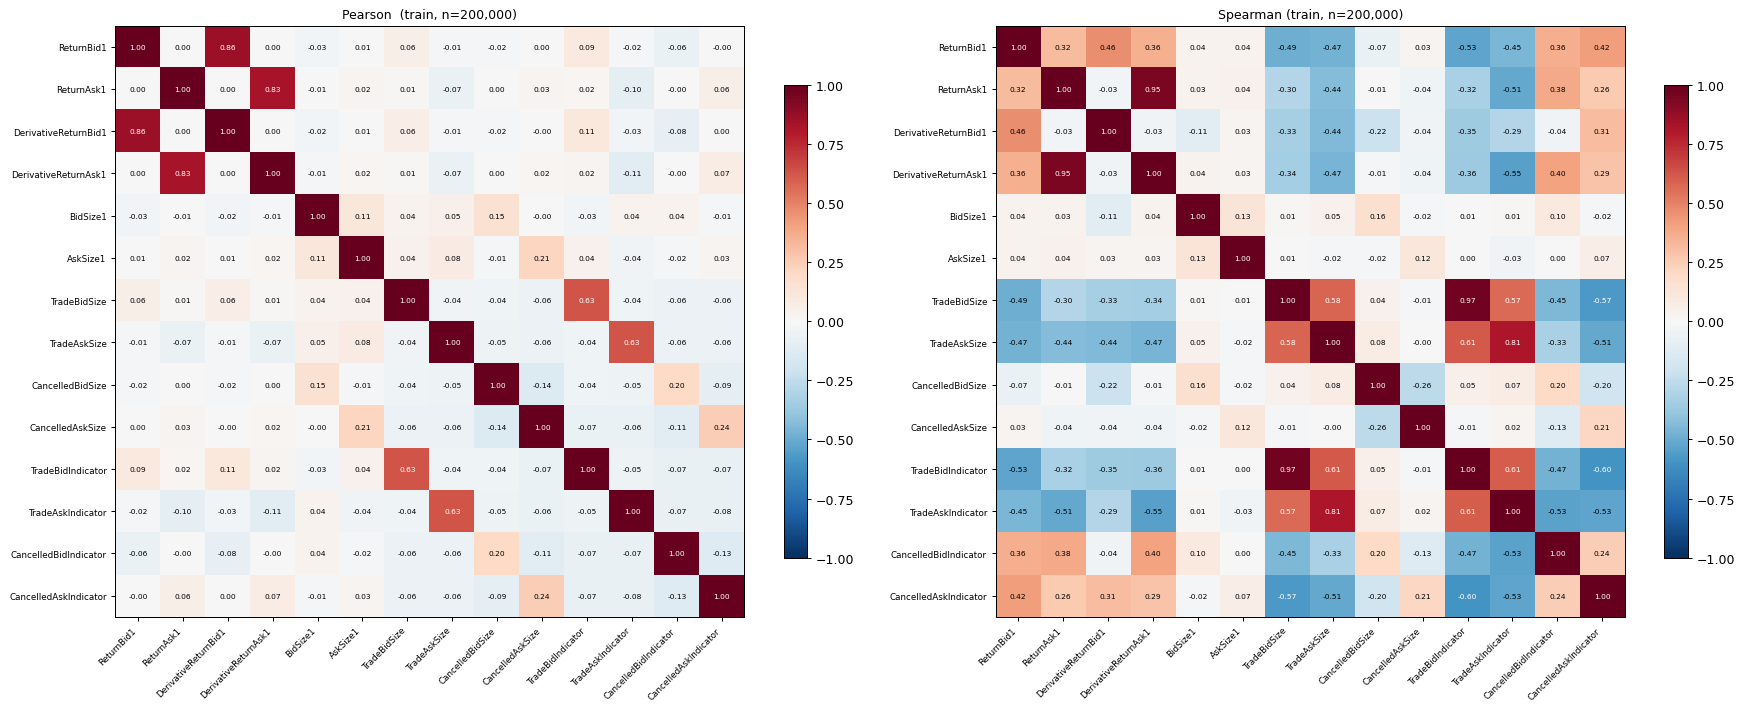

In [22]:
def plot_corr_heatmap(corr, ax, title):
    im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index, fontsize=7)
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            v = corr.iloc[i, j]
            ax.text(j, i, f'{v:.2f}',
                    ha='center', va='center',
                    fontsize=6,
                    color='white' if abs(v) > 0.55 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=10)

corr_sample = train[numeric_features].dropna().sample(200_000, random_state=42)
corr_pearson= corr_sample.corr(method='pearson')
corr_spearman = corr_sample.corr(method='spearman')

fig, axes= plt.subplots(1, 2, figsize=(20, 8))
plot_corr_heatmap(corr_pearson,  axes[0], f'Pearson  (train, n={len(corr_sample):,})')
plot_corr_heatmap(corr_spearman, axes[1], f'Spearman (train, n={len(corr_sample):,})')
plt.tight_layout()
plt.show()

### 4.2 Mahalanobis distance distribution

For each row in a 100K-row training sample, we compute the Mahalanobis distance from the training mean using the training covariance matrix. This gives us a simple joint anomaly score, because it measures how far each row is from the normal training distribution after accounting for relationships between features.

We also compare the squared Mahalanobis distances to a chi-square distribution with 14 degrees of freedom, since we have 14 numeric features. If the data were close to multivariate Gaussian, the QQ plot would roughly follow the diagonal line. Large deviations from that line would suggest heavy tails or non-Gaussian structure.

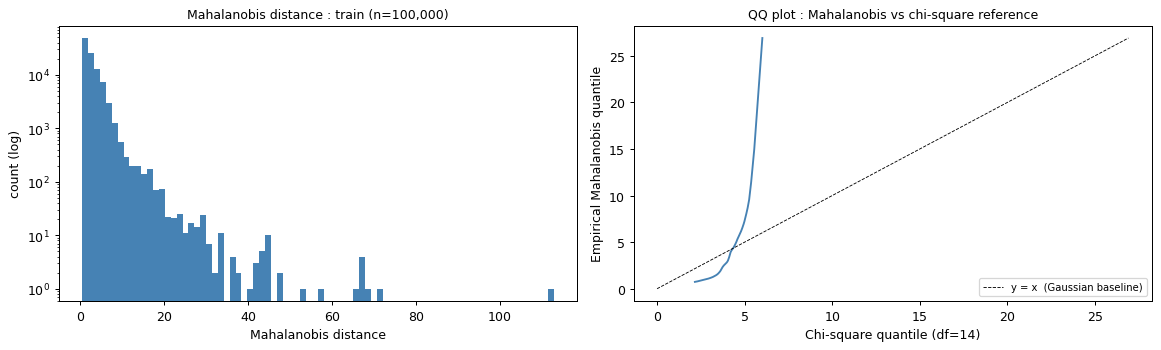

Mahalanobis distance percentiles (train sample)
  p   50:    2.045
  p   90:    5.330
  p   95:    6.530
  p   99:   12.163
  p 99.9:   26.911
  p99.99:   47.964


In [23]:
from scipy.stats import chi2

maha_sample_n = 100_000
maha_data = train[numeric_features].dropna().sample(maha_sample_n, random_state=42).to_numpy()

mean_vec= maha_data.mean(axis=0)
cov_mat = np.cov(maha_data.T)
inv_cov = np.linalg.pinv(cov_mat)

diff = maha_data - mean_vec
maha_sq = (diff @ inv_cov * diff).sum(axis=1)
maha = np.sqrt(np.clip(maha_sq, 0, None))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(maha, bins=80, color='steelblue', edgecolor='none')
axes[0].set_yscale('log')
axes[0].set_title(f'Mahalanobis distance : train (n={maha_sample_n:,})', fontsize=10)
axes[0].set_xlabel('Mahalanobis distance')
axes[0].set_ylabel('count (log)')

quantiles = np.linspace(0.01, 0.999, 200)
chi2_q = np.sqrt(chi2.ppf(quantiles, df=len(numeric_features)))
emp_q = np.quantile(maha, quantiles)
axes[1].plot(chi2_q, emp_q, color='steelblue', linewidth=1.5)
ref_max = max(chi2_q.max(), emp_q.max())
axes[1].plot([0, ref_max], [0, ref_max], 'k--', linewidth=0.7, label='y = x  (Gaussian baseline)')
axes[1].set_xlabel(f'Chi-square quantile (df={len(numeric_features)})')
axes[1].set_ylabel('Empirical Mahalanobis quantile')
axes[1].set_title('QQ plot : Mahalanobis vs chi-square reference', fontsize=10)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print('Mahalanobis distance percentiles (train sample)')
for pct in [50, 90, 95, 99, 99.9, 99.99]:
    print(f'  p{pct:>5}: {np.percentile(maha, pct):8.3f}')

The main takeaway from this section is that the normal data has clear joint feature structure, but it does not follow a simple Gaussian pattern.

In the correlation matrices from Section 5.1, the features naturally fall into blocks. Returns move closely with their derivative versions, trade sizes move with their matching indicators, and bid-side and ask-side variables form related groups. This matches the way we grouped the features earlier in the EDA, and it also shows that the 14 numeric features are not fully independent. There is some redundancy in the data, which supports the idea of using a compressed representation later, such as an autoencoder bottleneck.

The Mahalanobis plots in Section 5.2 show that a simple Gaussian assumption is not a great fit. The distance distribution has a long right tail, and the QQ plot moves well above the Gaussian reference line. This means that the normal data has heavier tails than a multivariate Gaussian would expect. This connects back to the mass spikes we saw in Section 1.3: some extreme-looking values are still part of normal behavior, so a Gaussian distance model may mis-score them.

These observations are good starting points for our modelling. First, the block structure suggests that a reconstruction-based model could work well because it can learn the normal relationships between features. Second, the non-Gaussian tails suggest that Mahalanobis distance should only be used as a baseline, not as the main model. Finally, because we already saw symbol-level differences earlier, especially for BidSize1, it may be better to compute anomaly scores per symbol rather than using one fully global distance score.

## 5. Manipulation Pattern Fingerprints

Sections 1 to 4 helped us understand what normal behavior looks like in the data. Section 5 connects that analysis to the modelling step by asking: if a manipulation pattern is present, what should it look like in our features?

For each pattern, we describe the intuition behind it, identify which existing columns should react, and define engineered features that may help capture it. We also look for early visual evidence in the test data, while checking whether the same pattern is mostly absent from normal train data.

The section focuses on three manipulation patterns: pump-and-dump, layering, and quote stuffing. It does not make final statistical claims yet. Instead, it gives us a feature-engineering plan that will be used in the modelling notebook.

### 5.1 Pump-and-dump

A pump happens when buying pressure pushes the price up quickly, and the dump happens when the price falls back after that movement.A pump-and-dump pattern would look like a sharp price movement in one direction, followed by a reversal.In our data, we cannot directly reconstruct the real price, but we can use the return columns as a shape proxy.

The columns that should react are mainly the return and trade-size features. ReturnBid1 and ReturnAsk1 should capture the directional movement, while DerivativeReturnBid1 and DerivativeReturnAsk1 should react when the movement accelerates or reverses. TradeBidSize and TradeAskSize should also matter because this type of pattern is usually linked to abnormal trading volume.

To capture this, we can engineer rolling cumulative return features over a fixed event window or time window. We can also build a reversal score that checks whether the next window moves in the opposite direction of the previous window. Finally, volume z-scores relative to a per-symbol baseline can help identify whether the move happened with unusually high trading activity.

The visualization below shows cumulative ReturnBid1 over time in the test set for one symbol. We use it only as a pattern proxy: long upward moves followed by sharp drops would be possible pump-and-dump candidates, but this plot is not a real price reconstruction.

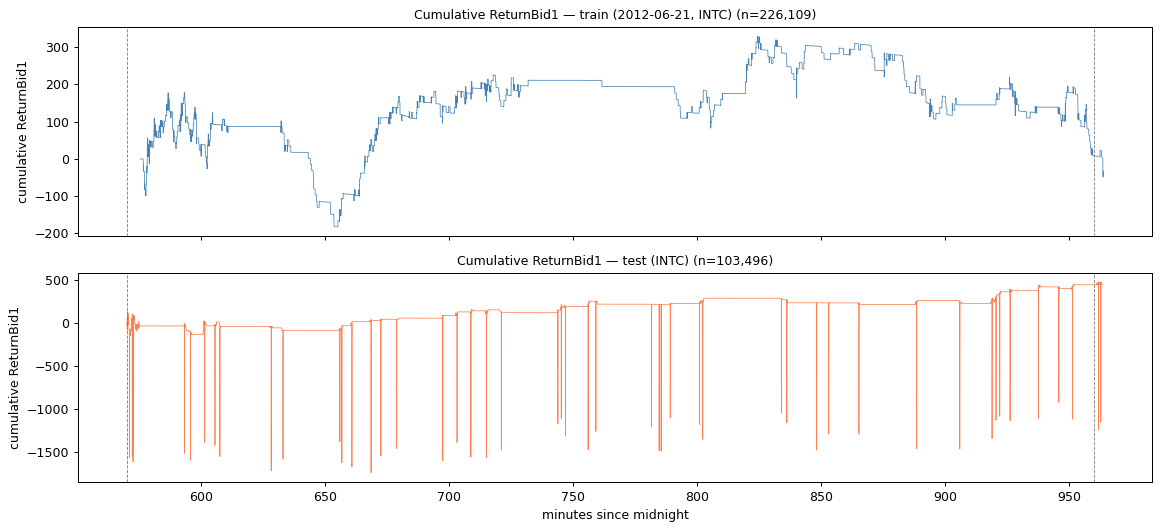

In [24]:
train_d = train.copy()
test_d = test.copy()

# print(f'common_date = {common_date}  (dtype: {test["Date"].dtype})')
# print(f'train_d rows: {len(train_d):,}   test_d rows: {len(test_d):,}')

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

for ax, (label, df, color) in zip(
    axes,
    [('train (2012-06-21, INTC)', train_d[train_d['ExternalSymbol'] == 'INTC'], 'steelblue'), ('test (INTC)', test_d[test_d['ExternalSymbol']   == 'INTC'], 'coral')]):
    sub = df.sort_values('TimeInMilliSecs').reset_index(drop=True)
    cum = sub['ReturnBid1'].cumsum()
    ax.plot(sub['TimeInMilliSecs'] / 60_000, cum.values, color=color, linewidth=0.6)
    ax.set_ylabel('cumulative ReturnBid1')
    ax.set_title(f'Cumulative ReturnBid1 — {label} (n={len(sub):,})', fontsize=10)
    ax.axvline(570, color='gray', linestyle='--', linewidth=0.7)
    ax.axvline(960, color='gray', linestyle='--', linewidth=0.7)

axes[1].set_xlabel('minutes since midnight')
plt.tight_layout()
plt.show()

### 5.2 Layering

Layering happens when large orders are placed on one side of the order book to create a false impression of demand or supply, then cancelled before they actually trade. In the data, this should look like high cancellation activity combined with low executed trading volume.

The main columns to watch are BidSize1 and AskSize1 for displayed depth, CancelledBidSize and CancelledAskSize for cancelled volume, and TradeBidSize and TradeAskSize for actual traded volume. The cancellation indicators also help capture how often cancellation events occur.

To capture this pattern, we can engineer features such as a cancel-to-trade ratio within each symbol and time window, displayed depth relative to traded volume, and the difference between cancelled and traded size on the same side of the book. These features are meant to highlight cases where there is a lot of displayed or cancelled activity but little actual trading.

The scatter plot below compares TradeBidSize and CancelledBidSize on a sample of test rows. Points in the upper-left area, with high cancellations and low trades, would be possible layering candidates because they break the usual relationship between trading and cancellation activity.

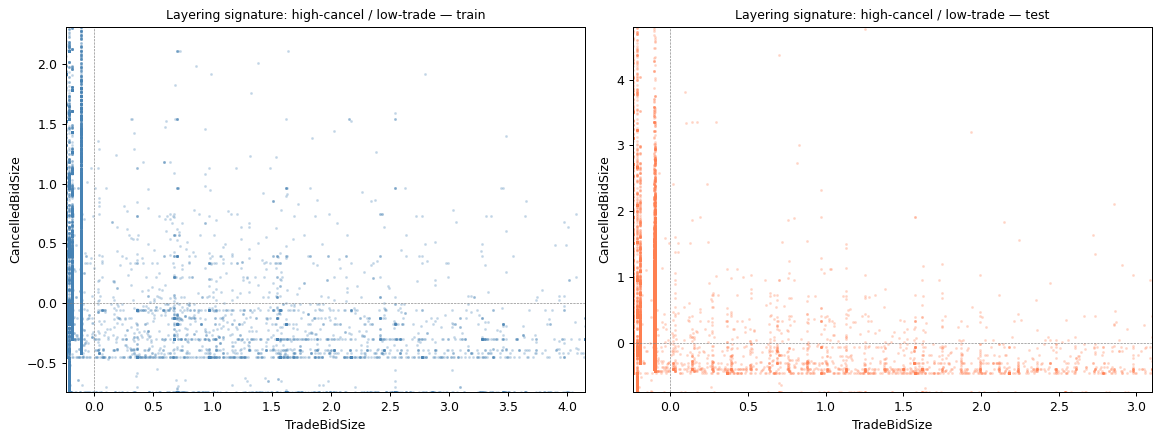

In [25]:
layer_train = train[['TradeBidSize', 'CancelledBidSize']].dropna().sample(50_000, random_state=42)
layer_test = test [['TradeBidSize', 'CancelledBidSize']].dropna().sample(min(50_000, len(test)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (label, df, color) in zip(axes, [('train', layer_train, 'steelblue'),('test',  layer_test,  'coral')]):
    ax.scatter(df['TradeBidSize'], df['CancelledBidSize'], s=2, alpha=0.2, color=color)
    p1x, p99x = df['TradeBidSize'].quantile([0.01, 0.99])
    p1y, p99y = df['CancelledBidSize'].quantile([0.01, 0.99])
    ax.set_xlim(p1x, p99x)
    ax.set_ylim(p1y, p99y)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_xlabel('TradeBidSize')
    ax.set_ylabel('CancelledBidSize')
    ax.set_title(f'Layering signature: high-cancel / low-trade — {label}', fontsize=10)
plt.tight_layout()
plt.show()

### 5.3 Quote stuffing

Quote stuffing happens when many orders are submitted and cancelled very quickly, creating an abnormal burst of market activity without much actual trading. In the data, this should appear as a very high event rate for a symbol, especially when trade activity stays low.

The main timing feature is TimeInMilliSecs, which lets us compute the gap between consecutive events. Very small inter-event gaps can indicate bursts. The cancellation indicators should increase during these bursts, while the trade indicators may stay low if the activity is mostly order submission and cancellation rather than executed trades.

To capture this, we can engineer rolling event-rate features by symbol, using either event windows or time windows. We can also compute a trade-rate-to-event-rate ratio, where low trade activity during a high-event-rate window would be suspicious. Another useful feature is the imbalance between cancellation indicators and trade indicators.

The visualization below compares train and test inter-event time distributions on a log10(Δt) scale. If quote stuffing is visible at the distribution level, the test curve should have more very small gaps than train. If the two curves look similar, then quote stuffing may only appear in short bursts, meaning window-based event-rate features will be more useful than the marginal Δt distribution alone.

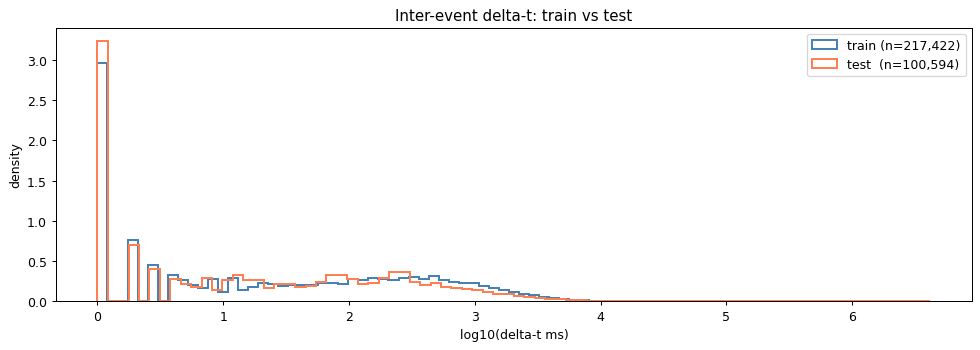

  p  1  train=     1.000  test=     1.000  ratio=1.000
  p  5  train=     1.000  test=     1.000  ratio=1.000
  p 25  train=     2.000  test=     1.000  ratio=0.500
  p 50  train=    20.000  test=    15.000  ratio=0.750
  p 75  train=   245.000  test=   160.000  ratio=0.653
  p 95  train=  1551.000  test=  1142.000  ratio=0.736
  p 99  train=  4318.000  test=  3873.140  ratio=0.897


In [26]:
train_s = train.sort_values(["ExternalSymbol","TimeInMilliSecs"]).reset_index(drop=True)
train_s["dt"]= train_s.groupby("ExternalSymbol")["TimeInMilliSecs"].diff()
train_dt_pos = train_s["dt"].dropna()
train_dt_pos = train_dt_pos[train_dt_pos > 0]

test_s = test.sort_values(["ExternalSymbol","TimeInMilliSecs"]).reset_index(drop=True)
test_s["dt"] = test_s.groupby("ExternalSymbol")["TimeInMilliSecs"].diff()
test_dt_pos = test_s["dt"].dropna()
test_dt_pos = test_dt_pos[test_dt_pos > 0]

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(np.log10(train_dt_pos), bins=80, density=True, histtype="step", color="steelblue", linewidth=1.6, label=f"train (n={len(train_dt_pos):,})")
ax.hist(np.log10(test_dt_pos),  bins=80, density=True, histtype="step", color="coral",     linewidth=1.6, label=f"test  (n={len(test_dt_pos):,})")
ax.set_xlabel("log10(delta-t ms)")
ax.set_ylabel("density")
ax.set_title("Inter-event delta-t: train vs test")
ax.legend()
plt.tight_layout()
plt.show()

for pct in [1, 5, 25, 50, 75, 95, 99]:
    tr_p = float(train_dt_pos.quantile(pct/100))
    te_p = float(test_dt_pos.quantile(pct/100))
    print(f"  p{pct:>3}  train={tr_p:>10.3f}  test={te_p:>10.3f}  ratio={te_p/tr_p:.3f}")


From the Section 6 plots, we can see that the three manipulation patterns would need different engineered signals. In the pump-and-dump plot, the useful information is the shape of cumulative ReturnBid1 over time: the suspicious areas are the sharp upward or downward runs followed by quick reversals, not one isolated return value. In the layering scatter plot, the important region is the high-cancel / low-trade area, where CancelledBidSize is large while TradeBidSize stays small. In the quote-stuffing Δt plot, train and test look fairly similar in the overall marginal distribution, so a single inter-event gap is probably not enough; the signal is more likely to appear in short local bursts of events.

So our models cannot rely on the original 14 raw columns. We need to turn these patterns into measurable signals that the models can actually use. The plots suggest a few concrete choices.

First, we compute some features directly on each row, especially the cancel-to-trade size ratio and displayed-vs-traded ratio. These are simple, but they directly target the layering pattern because they compare cancelled or displayed activity against actual executed trades.

Second, we compute sequential features within each (symbol, date) group after sorting by TimeInMilliSecs. This matters because pump-and-dump and quote stuffing are time-based patterns. For this, we calculate inter-event Δt, rolling event rates over windows such as 50, 200, and 1000 events, rolling sums of ReturnBid1 and ReturnAsk1 as cumulative return proxies, and rolling trade-event counts relative to total event counts as a quote-stuffing signal.

Third, we re-standardize BidSize1 per symbol before model fitting. Section 3 showed that BidSize1 was the feature with the clearest per-symbol scale difference, so using it globally could make one stock look artificially more or less abnormal than another.

Fourth, we train the main model on the 2012-06-21 subset of train, since Section 2 showed that this date best matches the test structure. The remaining multi-year train data can still be useful as a stability check, but the primary training distribution should be closer to the test distribution.



# Part 2 : Feature Engineering

## 6. Feature Engineering

The EDA showed that the manipulation patterns are not captured by one raw column alone. Some patterns appear as extreme values, some as unusual relationships between features, and others as repeated burst-like order activity. Because of this, we expand the 14 original numeric columns into 37 model-ready features.Thet are all fitted using only the normal traning data to avoid any leakage. 


We build four main groups of features. 

> - Raw features: First, we keep the 14 original numeric columns as baseline inputs, including returns, derivative returns, bid and ask sizes, trade sizes, cancellation sizes, and activity indicators. 
> -  Per-symbol z-score features: Second, we create per-symbol z-score features. The EDA showed that symbols have different natural scales, especially for size-related variables such as BidSize1, so we compute z-scores separately by symbol instead of using one pooled baseline. These z-scores measure how unusual each value is relative to what is normal for that same symbol. We create one z-score for each of the 14 raw features, plus max_zscore and mean_zscore to summarize row-level extremeness.

> - Magnitude and spread features: Third, we add magnitude and spread features. Since the EDA showed strong mass spikes around repeated no event values, these features help the model focus on departures from the usual low-activity state. This includes absolute return features, the maximum absolute feature value, and return_spread = |ReturnBid1 - ReturnAsk1|, which captures cases where the bid and ask returns stop moving together. 

> - Burst features: Finally, we create burst features from OriginalSequenceNumber. In the test set, some sequence numbers include hyphenated sub-IDs, meaning that one base order generated multiple related events. We extract the base sequence number, count how many rows share it, and create burst_log, burst_10_49, and burst_50plus. These features help capture quote-stuffing-style behavior, where the suspicious signal may appear as repeated rapid activity rather than as one extreme row.



In [27]:
def add_burst_features(df):
    df = df.copy()
    for col in ['base_seq','burst_size','burst_log','burst_10_49','burst_50plus']:
        if col in df.columns:
            df = df.drop(columns=[col])
    df['base_seq'] = df['OriginalSequenceNumber'].astype(str).str.split('-').str[0]
    burst_map = df.groupby('base_seq').size()
    df['burst_size']= df['base_seq'].map(burst_map)

    # burst_log: log-compressed count - reduces influence of extreme burst sizes
    df['burst_log'] = np.log1p(df['burst_size'])

    # burst_10_49: binary flag for the 175x fraud zone (size 10-49)
    df['burst_10_49']  = ((df['burst_size'] >= 10) & (df['burst_size'] < 50)).astype(float)

    # burst_50plus: binary flag for large bursts (still suspicious but smaller signal)
    df['burst_50plus'] = (df['burst_size'] >= 50).astype(float)

    return df


def compute_training_stats(normal_df):
    """
    Compute per-symbol mean and std from normal data only.
    These are used to compute z-scores for test rows.
    No test data is ever used here.
    """
    filled = normal_df[NUMERIC_FEATURES].fillna(0)
    stats = {}
    for sym in normal_df['ExternalSymbol'].unique():
        mask = (normal_df['ExternalSymbol'] == sym).values
        sub = filled.values[mask]
        stats[sym] = {
            col: (sub[:, j].mean(), max(sub[:, j].std(), 1e-9))
            for j, col in enumerate(NUMERIC_FEATURES)
        }
    stats['__global__'] = {
        col: (filled[col].mean(), max(filled[col].std(), 1e-9))
        for col in NUMERIC_FEATURES
    }
    return stats


def compute_zscores(df, stats):
    """
    For each test row, compute |z| = |value - training_mean| / training_std
    separately for each of the 14 features and each stock symbol.
    Uses only training statistics — no test data involved.
    """
    filled = df[NUMERIC_FEATURES].fillna(0).values
    zscores = np.zeros_like(filled)
    for sym in df['ExternalSymbol'].unique():
        mask = (df['ExternalSymbol'] == sym).values
        sym_stats = stats.get(sym, stats['__global__'])
        for j, col in enumerate(NUMERIC_FEATURES):
            mu, sig = sym_stats[col]
            zscores[mask, j] = np.abs((filled[mask, j] - mu) / sig)
    return zscores


def engineer_features(df, stats):
    """
    Build all 37 features:
    14 raw + 14 per-feature z-scores + 2 aggregate z-scores
    + 4 magnitude features + 3 burst features = 37 total
    """
    df = df.copy()
    df[NUMERIC_FEATURES] = df[NUMERIC_FEATURES].fillna(0)

    # z-scores (16 features)
    zscores = compute_zscores(df, stats)
    df['max_zscore'] = zscores.max(axis=1)   # worst single-feature deviation
    df['mean_zscore'] = zscores.mean(axis=1)  # average deviation across all features
    for j, col in enumerate(NUMERIC_FEATURES):
        df[f'z_{col}'] = zscores[:, j]

    # magnitude features (4 features)
    df['max_abs_feat']= df[NUMERIC_FEATURES].abs().max(axis=1)
    df['abs_RetBid1'] = df['ReturnBid1'].abs()
    df['abs_RetAsk1'] = df['ReturnAsk1'].abs()
    df['return_spread'] = (df['ReturnBid1'] - df['ReturnAsk1']).abs()

    feat_cols = (
        NUMERIC_FEATURES                          # 14 raw
        + ['max_zscore', 'mean_zscore']           # 2 aggregate z-scores
        + [f'z_{c}' for c in NUMERIC_FEATURES]   # 14 per-feature z-scores
        + ['max_abs_feat', 'abs_RetBid1', 'abs_RetAsk1', 'return_spread']  # 4 magnitude
        + ['burst_log', 'burst_10_49', 'burst_50plus']                     # 3 burst
    )                                             # total: 37
    return df, df[feat_cols].fillna(0).values


# Run feature engineering
stats = compute_training_stats(normal)
normal = add_burst_features(normal)
test = add_burst_features(test)
normal, X_normal = engineer_features(normal, stats)
test,   X_test = engineer_features(test,   stats)

print(f"\nFeature matrix:")
print(f"  Normal :{X_normal.shape}")
print(f"  Test: {X_test.shape}")  # used only for SCORING
print(f"\nBurst size distribution in test data:")
for bin_label, low, high in [('Single (normal)',1,2),('2-9 (normal)',2,10),('10-49 (FRAUD)',10,50),('50+ (suspicious)',50,999)]:
    n = ((test['burst_size'] >= low) & (test['burst_size'] < high)).sum()
    print(f" {bin_label:<2}:{n:,} rows")



Feature matrix:
  Normal :(1537961, 37)
  Test: (289101, 37)

Burst size distribution in test data:
 Single (normal):46,817 rows
 2-9 (normal):197,503 rows
 10-49 (FRAUD):12,768 rows
 50+ (suspicious):32,013 rows


In [28]:
# Build feature matrices for all downstream models
stats = compute_training_stats(normal)
normal_fe = add_burst_features(normal)
test_fe = add_burst_features(test)
normal_fe, X_normal = engineer_features(normal_fe, stats)
test_fe,   X_test= engineer_features(test_fe,   stats)

val_fe = add_burst_features(val)
val_fe, X_val = engineer_features(val_fe, stats)

feat_names = (
    NUMERIC_FEATURES
    + ['max_zscore', 'mean_zscore']
    + [f'z_{c}' for c in NUMERIC_FEATURES]
    + ['max_abs_feat', 'abs_RetBid1', 'abs_RetAsk1', 'return_spread']
    + ['burst_log', 'burst_10_49', 'burst_50plus']
)

print(f'Feature matrix (normal): {X_normal.shape}  (used to fit all models)')
print(f'Feature matrix (test) : {X_test.shape}  (scored only)')


Feature matrix (normal): (1537961, 37)  (used to fit all models)
Feature matrix (test) : (289101, 37)  (scored only)


## 7. Scale Features

Before modelling, we scale the engineered feature set using RobustScaler. The scaler is fit only on the normal training data and then applied to the test set, so no information from test is used during fitting.

We use RobustScaler because it relies on the median and interquartile range rather than the mean and standard deviation. This makes it less sensitive to extreme values, which is important in anomaly detection because the most unusual observations should not control the scaling.

In [29]:
# Fit scaler on NORMAL data, apply same transform to TEST
# Never fit_transform on test - that would use test statistics (data leakage)
scaler = RobustScaler()
X_n_sc = scaler.fit_transform(X_normal)   # fit + transform on normal
X_t_sc = scaler.transform(X_test)         # transform only on test

print(f"Scaled normal matrix: {X_n_sc.shape}")
print(f"Scaled test matrix: {X_t_sc.shape}")
print(f"\nReturnBid1 after scaling:")
print(f"  Normal mean:{X_n_sc[:, 0].mean():.4f}  ")
print(f"  Normal std: {X_n_sc[:, 0].std():.4f} ")
print(f"  Test max: {X_t_sc[:, 0].max():.4f}  ")


Scaled normal matrix: (1537961, 37)
Scaled test matrix: (289101, 37)

ReturnBid1 after scaling:
  Normal mean:1.1255  
  Normal std: 310.4364 
  Test max: 104580.3041  



# Part 3 : Simple Models

To start the modelling stage, we began with the models we had already seen in class. The idea was to try a few different approaches, submit them separately to Kaggle, compare their scores, and then decide which modelling direction was worth improving. We tested Logistic Regression, Random Forest, SVM, and a Dense Autoencoder. These models were not chosen randomly; they were motivated by the EDA and by the feature engineering step.

Logistic Regression was used as the simplest supervised baseline. It tests whether the engineered features, especially the z-scores, magnitude features, and burst indicators, create a mostly linear separation between normal rows and injected anomalies. If Logistic Regression performs well, it means the anomaly signal is already quite direct and does not require a very complex model.

Random Forest was used because the EDA suggested that some manipulation patterns depend on interactions between features. For example, a burst may only become suspicious when it appears together with abnormal returns, high cancellations, or unusual trade-size behavior. Random Forest can capture these non-linear combinations better than Logistic Regression.

SVM was included as another supervised model with a different decision-boundary logic. It helps test whether a margin-based classifier can separate the injected anomalies from the normal data. This gives us another benchmark before moving to anomaly-specific methods.

Finally, the Dense Autoencoder was motivated by the joint feature structure observed in the EDA. The correlation heatmaps showed that the features are not independent and that there is redundancy across bid-side, ask-side, return, size, and indicator blocks. The autoencoder uses this structure by learning how to reconstruct normal data. Rows that reconstruct poorly can then be treated as more suspicious.

Because the train and validation sets are 100% normal, the supervised models required synthetic anomaly injection. This makes them useful as first benchmarks, but also creates a limitation: they can only learn fraud patterns that resemble the injected anomalies. This is why we also tested the autoencoder as a more natural anomaly detection model.







## 8. Setup : labeled dataset for supervised 

The main issue with the labels is that train and validation contain only normal rows, while the test labels are hidden. So, if we want to train supervised models like Logistic Regression, Random Forest, or SVM, we need to create a labelled binary dataset ourselves. To do this, we use synthetic anomaly injection: we start with normal training rows, artificially perturb some of them to look abnormal, label those rows as fraud, and then train the model to separate normal rows from injected anomalies. The limitation is that this injection mostly creates return-magnitude anomalies, so it is closest to pump-and-dump behavior. It does not directly simulate layering or quote stuffing, meaning the supervised models may be biased toward return-based anomalies.

In [30]:
def inject_synthetic_anomalies(df, n_synth, seed):
    """Sample n_synth rows, scale the return columns by [10,50]x, label as fraud."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(df), n_synth, replace=False)
    s   = df.iloc[idx].copy().reset_index(drop=True)
    scale_bid = rng.uniform(10, 50, n_synth)
    scale_ask = scale_bid * rng.uniform(0.8, 1.2, n_synth)
    s['ReturnBid1'] *= scale_bid
    s['ReturnAsk1'] *= scale_ask
    s['DerivativeReturnBid1'] *= scale_bid
    s['DerivativeReturnAsk1'] *= scale_ask
    return s

N_NORMAL, N_SYNTH = 100_000, 20_000
rng = np.random.default_rng(42)

labeled_normal = normal.iloc[rng.choice(len(normal), N_NORMAL, replace=False)].copy().reset_index(drop=True)
labeled_synth = inject_synthetic_anomalies(normal, N_SYNTH, seed=43)

labeled = pd.concat([labeled_normal, labeled_synth], ignore_index=True)
# Re-engineer features so z-scores reflect the perturbed values
labeled = add_burst_features(labeled)
labeled, X_labeled = engineer_features(labeled, stats)
y_labeled = np.array([0]*N_NORMAL + [1]*N_SYNTH)

# Separate scaler for supervised models (fit on the labeled mix, not normal-only)
sup_scaler = RobustScaler()
X_labeled_sc = sup_scaler.fit_transform(X_labeled)
X_test_sup = sup_scaler.transform(X_test)

print(f'Labeled dataset: {X_labeled.shape}  |  {y_labeled.sum():,} fraud / {(y_labeled==0).sum():,} normal')


Labeled dataset: (120000, 37)  |  20,000 fraud / 100,000 normal


## 9. Model 1 : Logistic Regression

Linear baseline. Each test row gets a fraud probability from a logistic of a weighted sum of the 37 features. We expect this to perform reasonably well for the synthetic-anomaly type (return-magnitude perturbations are roughly linearly separable in z-score space), but to under-perform on more subtle joint-structure anomalies.We use RobustScale (median + IQR) rather than StandardScaler because the EDA showed several columns have heavy mass at one value plus long tails -  the median/IQR scaler is less distorted by those tails than mean/std.

We use max_iter=500 to give the solver enough iterations to converge on 120K rows without cutting it short, and n_jobs=-1 to use all available cores since the default single-threaded solver is slow at this scale.

In [31]:
lr = LogisticRegression(max_iter=500, random_state=42, n_jobs=-1)
lr.fit(X_labeled_sc, y_labeled)

lr_test = lr.predict_proba(X_test_sup)[:, 1]

coef = lr.coef_[0]
top  = np.argsort(np.abs(coef))[::-1][:5]
print('Top-5 LR features:')
for i in top:
    print(f'  {feat_names[i]:30s}  {coef[i]:+.4f}')

sub = pd.DataFrame({'ID': test['ID'].values, 'TARGET': lr_test})
sub.to_csv(f'{OUTPUT_DIR}submission_logistic_regression.csv', index=False)
print(f'\nSaved submission_logistic_regression.csv')


Top-5 LR features:
  burst_log                       -0.6220
  mean_zscore                     +0.5471
  CancelledAskSize                -0.2675
  CancelledBidSize                -0.2587
  max_abs_feat                    +0.2574

Saved submission_logistic_regression.csv


## 10. Model 2 : Random Forest

Random Forest is our second supervised model because it can capture feature interactions that Logistic Regression may miss. This matters for our engineered features because suspicious behavior may depend on combinations, such as a medium burst size together with a high max_zscore, rather than on one feature alone. This also matches the EDA, where the burst signal was strongest in a specific range instead of increasing smoothly across all burst sizes.

We train the Random Forest on the same labelled dataset as Logistic Regression. Since trees split based on value thresholds and rank order, scaling is not needed, so we use X_labeled directly. We set n_estimators=100 to get stable predictions without making training too slow. max_depth=15 limits how deep each tree can grow, and min_samples_leaf=20 prevents the model from creating tiny leaves that memorize noise in the 120K-row synthetic dataset. We also look at the top feature importances to see whether Random Forest is using the same signals as Logistic Regression or capturing complementary patterns.

In [32]:
rf = RandomForestClassifier(n_estimators=100, max_depth=15,min_samples_leaf=20, n_jobs=-1, random_state=42)
rf.fit(X_labeled, y_labeled)   # RF doesn't need scaling

rf_test = rf.predict_proba(X_test)[:, 1]

imp = rf.feature_importances_
top = np.argsort(imp)[::-1][:5]
print('Top-5 RF feature importances:')
for i in top:
    print(f'  {feat_names[i]:30s}  {imp[i]:.4f}')

sub = pd.DataFrame({'ID': test['ID'].values, 'TARGET': rf_test})
sub.to_csv(f'{OUTPUT_DIR}submission_random_forest.csv', index=False)
print(f'\nSaved submission_random_forest.csv')


Top-5 RF feature importances:
  z_DerivativeReturnAsk1          0.1745
  abs_RetBid1                     0.1255
  ReturnAsk1                      0.1181
  z_DerivativeReturnBid1          0.1135
  DerivativeReturnAsk1            0.0924

Saved submission_random_forest.csv


## 11. Model 3 : SVM (Linear)

We include a Linear SVM to add a different supervised modelling approach. Unlike Logistic Regression, which fits probabilities by minimizing log-loss, SVM focuses on finding the maximum-margin boundary between normal and synthetic fraud rows. This makes it useful as a complementary model because it may make different mistakes from Logistic Regression and Random Forest.
We use LinearSVC instead of an RBF-kernel SVM because the labelled dataset has 120K × 37 observations, and an RBF SVM would be too expensive in memory and time. LinearSVC scales much better for this setting. Since SVM is sensitive to feature scale, we train it on the scaled labelled features, X_labeled_sc. We keep C=1.0 as the standard regularization setting, increase max_iter=3000 to help convergence, and use dual='auto' so sklearn chooses the faster formulation based on the sample-feature shape.
Since LinearSVC returns a signed decision score rather than a probability, we min-max normalize the decision function to [0, 1] before creating the submission. This gives us a ranking score comparable to the LR/RF outputs, but it should not be interpreted as a calibrated fraud probability.

In [33]:
# This function is the min_max normalization function (we use this quite often)
def minmax_01(a):
    lo, hi = a.min(), a.max()
    return (a - lo) / (hi - lo + 1e-9)

In [34]:
svm = LinearSVC(C=1.0, max_iter=3000, dual='auto', random_state=42)
svm.fit(X_labeled_sc, y_labeled)

svm_test = minmax_01(svm.decision_function(X_test_sup))

coef = svm.coef_[0]
top = np.argsort(np.abs(coef))[::-1][:5]
print('Top-5 SVM features:')
for i in top:
    print(f'  {feat_names[i]:30s}  {coef[i]:+.4f}')

sub = pd.DataFrame({'ID': test['ID'].values, 'TARGET': svm_test})
sub.to_csv(f'{OUTPUT_DIR}submission_svm.csv', index=False)
print(f'\nSaved submission_svm.csv ')


Top-5 SVM features:
  return_spread                   -4.8876
  abs_RetAsk1                     +2.0565
  max_zscore                      -1.4571
  max_abs_feat                    +1.0735
  mean_zscore                     +0.4667

Saved submission_svm.csv 


## 12. Model 4 : Dense Autoencoder (INCLUDE REASON + MATH)

The Dense Autoencoder is the first model we use that does not need labels or synthetic anomaly injection. Instead of learning from normal vs fraud examples, it is trained only on the normal data and learns to reconstruct the 37 engineered features. it's the first unsupervised model we used in this context. The logic is that normal rows should be easy to reconstruct because they follow patterns the model has seen during training, while abnormal rows should reconstruct worse and receive a higher anomaly score.

the architecture of the autoencoder was chosen as follow 37 -> 20 -> 8 -> 20 -> 37, using hidden_layer_sizes=(20, 8, 20).The 8-unit bottleneck forces the model to compress the input features before rebuilding them, which matches what we saw in Section 5: the features have block structure and redundancy, so the normal data should be representable in a smaller space.

We train the model on the full normal pool of 1.54M rows, with max_iter=50 and batch_size=1024. After training, we compute the reconstruction error on each test row and use that error as the anomaly score. Rows that the autoencoder reconstructs poorly are treated as more suspicious.


In [35]:
# Separate scaler for AE — fit on full normal pool
ae_scaler = RobustScaler()
X_normal_sc = ae_scaler.fit_transform(X_normal)
X_test_ae = ae_scaler.transform(X_test)

ae = MLPRegressor(hidden_layer_sizes=(20, 8, 20), activation='relu', solver='adam', learning_rate_init=0.001, max_iter=50, batch_size=1024, random_state=42, verbose=False)
ae.fit(X_normal_sc, X_normal_sc)   # input = output
print(f'Training loss: {ae.loss_:.6f}')

recon_err = np.mean((X_test_ae - ae.predict(X_test_ae))**2, axis=1)
ae_test = minmax_01(recon_err)

sub = pd.DataFrame({'ID': test['ID'].values, 'TARGET': ae_test})
sub.to_csv(f'{OUTPUT_DIR}submission_autoencoder.csv', index=False)
print(f'\nSaved submission_autoencoder.csv')


Training loss: 2.587008

Saved submission_autoencoder.csv


## 13. INITIAL RESULTS OF SIMPLE MODELS ALONE


By submitting each model individually to Kaggle, we reached the following scores:
> - SVM : 0.68756
> - Logistic Regression : 0.71748
> - Random Forest : 
> - Autoencoder : 0.95498

The Autoencoder came out clearly on top. It was also the only unsupervised model in this section and that distinction matters. The three supervised models were all trained on the same synthetic injection: return columns scaled up by a random factor to simulate fraud. This means they mainly learned what a return-magnitude spike looks like. They are useful for that specific pattern, but they are limited when the anomaly does not look like the injected examples. This matters because the EDA identified three manipulation patterns, and only one of them is strongly related to return spikes. Pump-and-dump can appear through large return movements, but layering and quote stuffing may not. Layering is more about high cancellation relative to trade activity, possibly at moderate return levels. Quote stuffing is more about bursts of rapid repeated events, not necessarily one extreme return value. Since our synthetic positives did not directly simulate those two patterns, LR, RF, and SVM all share the same structural limitation: they can only detect what their training labels taught them to detect.

The Autoencoder does not rely on synthetic fraud labels. Instead, it learns what normal rows look like and flags rows that reconstruct poorly. This explains why it performed much better than the supervised models: it was not restricted to one injected fraud pattern.

At this point we wanted to understand whether combining the Autoencoder with the best supervised model  could push the score higher. The reasoning was that RF might capture non-linear feature combinations that the Autoencoder could miss, while the Autoencoder could detect abnormal patterns that were never included in the synthetic labels.


## 14. Ensemble : RF + AE a supervised and unsupervised model  

We average the normalised scores of RF and SVM. RF covers non-linear interactions;
SVM provides a different decision boundary on the same synthetic-anomaly space.

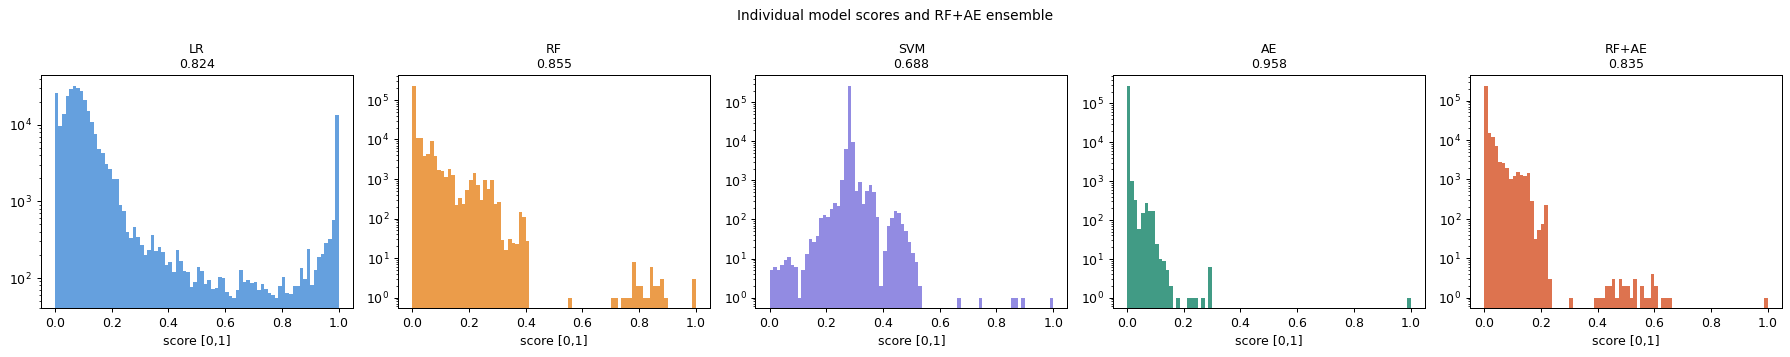

Saved submission_ensemble_rf_ae.csv 


In [37]:
ensemble_simple = minmax_01((rf_test + ae_test) / 2.0)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, score, label, color in zip(axes,
    [lr_test, rf_test, svm_test, ae_test, ensemble_simple],
    ['LR\n0.824', 'RF\n0.855', 'SVM\n0.688', 'AE\n0.958', 'RF+AE\n0.835'],
    ['#4A90D9','#E88B2A','#7F77DD','#1F8A70','#D85A30']):
    ax.hist(score, bins=80, color=color, alpha=0.85, edgecolor='none')
    ax.set_yscale('log'); ax.set_title(label, fontsize=10); ax.set_xlabel('score [0,1]')
plt.suptitle('Individual model scores and RF+AE ensemble', fontsize=11)
plt.tight_layout(); plt.show()

sub = pd.DataFrame({'ID': test['ID'].values, 'TARGET': ensemble_simple})
sub.to_csv(f'{OUTPUT_DIR}submission_ensemble_rf_ae.csv', index=False)
print('Saved submission_ensemble_rf_ae.csv ')


After submitting the ensemble on Kaggle, we get a score of **0.88376**.The ensemble did not beat the Autoencoder alone.  At first, we expected that combining two decent detectors would improve the score, because Random Forest and the Autoencoder use different modelling logic. RF learns tree-based rules from labelled examples, while the Autoencoder learns to reconstruct normal data.
However, the diversity between them was smaller than it appeared. Both models operate on the same 37-feature set, and both were ultimately blind to the same two manipulation types ; layering and quote stuffing ; that the synthetic injection never simulated. RF failed on them because its training labels only described magnitude spikes. The Autoencoder partially failed on them too, not because of the labels, but because a bottleneck of 8 units trained on 1.54 million normal rows will compress the most common normal patterns and may not preserve the subtle joint-feature signatures that layering and quote stuffing leave behind. When you average two models that are missing the same signal, you do not recover that signal you just get a smoother version of the same gap.

The Autoencoder performed better because it did not depend on synthetic fraud labels. It learned the normal structure of the data and flagged rows that reconstructed poorly. But when we averaged it with RF, the RF signal was still shaped by the return-spike injection, so the ensemble inherited part of that limitation instead of adding a truly new perspective.

The real ceiling was not the models themselves;  it was the source of supervision. Every supervised model is bounded by what the synthetic injection simulates, and pairing one with the Autoencoder carried that constraint into the combined score. No amount of weight tuning would fix a limitation that was baked into the training data.
At this point we had hit a ceiling and weren't sure how to push further. So we went back to the literature.


# Part 4:  Advanced Anomaly Detectors

Going through papers on anomaly detection in high-frequency markets, we first came across Isolation Forest. This model is similar to Random Forest in the sense that it also builds many trees, but the purpose is different. Random Forest uses labelled data to predict a class, while Isolation Forest does not need labels. Instead, it measures how quickly a data point gets isolated from the rest of the data. The intuition is that normal rows sit in dense regions and require many splits to separate, while anomalous or fraud-like rows sit in sparse regions and get cut off much faster.
We decided it to look at this model in isolation and then ensemble it with the AE


## 15. Isolation Forest
In this part, we use Isolation Forest as another unsupervised anomaly detector. We first explain the math behind the method, especially how random splits create isolation paths and how shorter path lengths translate into higher anomaly scores. Then, we connect that logic to our code implementation. In our code, the model builds 400 decision trees that randomly split the feature space. Each tree isolates observations differently, and the final anomaly score is based on the average isolation behavior across all trees.

We test Isolation Forest on its own first to see how well it performs as a standalone detector. Then, we ensemble it with the Autoencoder, because both models are unsupervised but capture different types of structure: the Autoencoder focuses on reconstruction error, while Isolation Forest focuses on how isolated a row is in feature space.

> ## The logic behind the model


For one isolation tree, the algorithm starts with a dataset $X$ at depth $d$. If there is only one observation left, or if the maximum depth has been reached, the algorithm stops and returns a leaf with depth $d$:

$$
\text{if } |X| \leq 1 \text{ or } d \geq d_{\max}: \quad \text{return leaf with depth } d
$$

Otherwise, the tree randomly selects one feature from the available $F$ features:

$$
q \leftarrow \text{Uniform}\{1, \ldots, F\}
$$

Then it randomly selects a split threshold between the minimum and maximum value of that feature:

$$
p \leftarrow \text{Uniform}[\min(X_q),\, \max(X_q)]
$$

Using this random threshold, the data is split into a left and right subset:

$$
X_L = \{x \in X : x_q \leq p\}, 
\qquad
X_R = \{x \in X : x_q > p\}
$$

The tree then continues recursively on both sides:

$$
\text{return} \; 
\text{Node}\left(q,\, p,\; \text{IsolationTree}(X_L, d{+}1),\; \text{IsolationTree}(X_R, d{+}1)\right)
$$

The important output of an isolation tree is the path length. For a test point $x$, the path length $h(x)$ is the number of edges the point travels from the root node to the leaf where it is isolated. Since the Isolation Forest is an ensemble of many isolation trees, we average the path length across all $T$ trees:

$$
E[h(x)] = \frac{1}{T} \sum_{t=1}^{T} h_t(x)
$$

This is what makes the method useful for anomaly detection. A point that lies in a sparse or unusual region of the data is usually isolated quickly, so it has a small average path length $E[h(x)]$. A normal point, which lies in a dense region with many similar observations, usually requires more splits before it can be isolated, so it has a larger average path length.

To interpret the path length, Isolation Forest uses a normalization constant $c(n)$, which represents the expected path length in a Binary Search Tree built from $n$ samples:

$$
c(n) = 2H(n-1) - \frac{2(n-1)}{n}
$$

where

$$
H(k) = \ln(k) + \gamma
$$

and $\gamma \approx 0.5772$ is the Euler–Mascheroni constant. This constant gives us a reference for what a typical path length should look like when the data behaves normally.

The original Isolation Forest anomaly score from Liu et al. is:

$$
s(x, n) = 2^{\;-\,E[h(x)]\,/\,c(n)}
$$

This formula means that points with shorter path lengths receive higher anomaly scores. If a point is isolated very quickly, then

$$
s \to 1 
\iff 
E[h(x)] \ll c(n)
\quad
\text{(isolated quickly } \Rightarrow \text{ anomalous)}
$$

If the point has an average path length close to the expected normal path length, then

$$
s \to 0.5 
\iff 
E[h(x)] = c(n)
\quad
\text{(average path } \Rightarrow \text{ indeterminate)}
$$

If the point is difficult to isolate, meaning it behaves more like the normal observations, then

$$
s \to 0 
\iff 
E[h(x)] \gg c(n)
\quad
\text{(hard to isolate } \Rightarrow \text{ normal)}
$$

In our implementation, we use `sklearn`, which returns `score_samples(x)`. This score is a signed version related to the path length, where more abnormal observations are associated with lower raw values. To make the direction easier to interpret, we negate the scores and then min-max normalize them to the range $[0,1]$:

$$
\text{score}_{\text{IF}}(i) =
\frac{-\text{score\_samples}(x_i) - \min_j}
{\max_j - \min_j + \varepsilon}
$$

Here, the small $\varepsilon$ is added to avoid division by zero. After this transformation, a higher $\text{score}_{\text{IF}}(i)$ means that the observation is more likely to be anomalous.

This method also connects directly to Random Forest from Chapter 7. In a Random Forest, we train many decision trees and average their predictions to reduce prediction error. In Isolation Forest, we also train many trees, but instead of averaging predictions, we average the isolation path lengths:

$$
E[h(x)] = \frac{1}{T}\sum_t h_t(x)
$$

So the ensemble idea is the same, but the goal is different. Random Forest is supervised and requires labels $Y$, while Isolation Forest is fully unsupervised and only tries to measure how easy it is to isolate each point. The Krogh–Vedelsby ensemble result from Chapter 7 is also useful here:

$$
E_{\text{ensemble}} = \bar{E} - \bar{A}
$$

This means that ensemble performance improves when the individual models are both accurate and diverse. In the context of Isolation Forest, the randomness in feature selection, threshold selection, and subsampling creates diverse trees. This diversity helps stabilize the average path length estimate and makes the final anomaly score more reliable.




In [38]:
iforest = IsolationForest(
    n_estimators = 400,
    max_samples = 512,
    contamination = 0.01,
    n_jobs = -1,
    random_state = 42,
)
iforest.fit(X_n_sc)   # normal data only

if_raw = -iforest.score_samples(X_t_sc)
if_sc = minmax_01(if_raw)

print('Isolation Forest:')
for t in [0.5, 0.7, 0.9]:
    print(f'  score >{t}: {(if_sc > t).sum():,} rows')

sub = pd.DataFrame({'ID': test['ID'].values, 'TARGET': if_sc})
sub.to_csv(f'{OUTPUT_DIR}submission_isolation_forest.csv', index=False)
print(f'\nSaved submission_isolation_forest.csv')


Isolation Forest:
  score >0.5: 41,895 rows
  score >0.7: 24,831 rows
  score >0.9: 289 rows

Saved submission_isolation_forest.csv


## 16. Ensembling two unsupervised models : Isolation forest and autoencoders

 IF and the AE complement each other: IF finds multivariate outliers in the 37-dimensional feature space, while the AE flags rows that don't reconstruct under the learned normal manifold. We pair them at equal weights and see if the combination beats either alone.

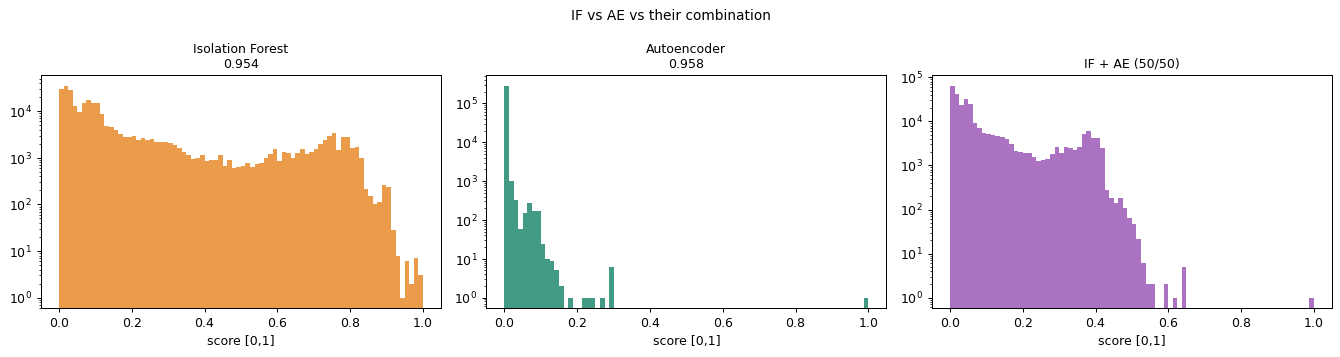

Saved submission_if_ae.csv


In [39]:
# ae_sc here uses the same AE scores from Part 3 (ae_test)
ae_sc = ae_test.copy()

if_ae = minmax_01((if_sc + ae_sc) / 2.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, score, label, color in zip(axes,
    [if_sc, ae_sc, if_ae],
    ['Isolation Forest\n0.954', 'Autoencoder\n0.958', 'IF + AE (50/50)'],
    ['#E88B2A','#1F8A70','#9B59B6']):
    ax.hist(score, bins=80, color=color, alpha=0.85, edgecolor='none')
    ax.set_yscale('log'); ax.set_title(label, fontsize=10); ax.set_xlabel('score [0,1]')
plt.suptitle('IF vs AE vs their combination', fontsize=11)
plt.tight_layout(); plt.show()

sub = pd.DataFrame({'ID': test['ID'].values, 'TARGET': if_ae})
sub.to_csv(f'{OUTPUT_DIR}submission_if_ae.csv', index=False)
print('Saved submission_if_ae.csv')


When submitting the file on kaggle, we reached a result **0.95379**, but it still did not clearly beat the Autoencoder. This told us that Isolation Forest was useful as another unsupervised benchmark, but it was not enough on its own to fully capture the strongest anomaly signal in the test set.
After that, we wanted to try another approach we found in the anomaly detection literature: a z-score based detector. The idea is much simpler than Isolation Forest or the Autoencoder. Instead of training a model, we measure how far each test value is from the normal training distribution, in standard deviation units. Since the EDA showed that symbols have different natural scales, we compute these z-scores per symbol rather than globally.

This approach also fit naturally with our feature engineering step because we had already created per-symbol z-score features. At first, these features were meant to be inputs for the supervised models, but after reviewing the literature, we realized they could also be used directly as an anomaly score. In other words, if a row has very large deviations from what is normal for its symbol, it should be ranked as more suspicious.

Similar to what we did with Isolation Forest, we first introduce the logic behind the z-score detector, then explain how we implement it, test how well it performs as a standalone detector, and finally check whether ensembling it with the Autoencoder improves the Kaggle score.

## 17. Z SCORE

In this part, we use a statistical z-score approach to detect observations that look unusual compared to the normal training data. The main idea is that a value is suspicious when it is very far from what is normally observed for the same stock symbol. Since each symbol has its own behavior and volatility, we do not compare all stocks using one global mean and standard deviation. Instead, we compute the statistics separately for each symbol using only the normal training rows.

For a set of $n$ training observations $x_1, x_2, \ldots, x_n$, the mean is computed as:

$$
\mu = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

and the standard deviation is computed as:

$$
\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2}
$$

The z-score tells us how many standard deviations an observation is away from the mean. For one observation $x_i$, the z-score is:

$$
z_i = \frac{x_i - \mu}{\sigma}
$$

Because anomalies can happen in both directions, meaning a value can be unusually high or unusually low, we use the absolute value of the z-score:

$$
|z_i| = \frac{|x_i - \mu|}{\sigma}
$$

In the code, the z-score is computed per symbol and per feature. For a test row $i$, feature $f$, and symbol $s$, we calculate:

$$ |z_{i,f,s}| = {\frac{|x_{i,f} - \mu_{f,s}|}{\sigma_{f,s}}}$$

where $\mu_{f,s}$ and $\sigma_{f,s}$ are the mean and standard deviation of feature $f$ computed only from the normal training rows for symbol $s$. This is important because a value that is extreme for one stock may be normal for another stock.

After computing the z-score for each feature, we summarize the feature-level z-scores using two main statistics. The first one is the maximum absolute z-score across all features:

$$
z_{\max,i} = \max_{f} |z_{i,f,s}|
$$

This captures the strongest abnormal signal in the row. The second one is the average absolute z-score across all $F$ features:

$$
\bar{z}_i = \frac{1}{F} \sum_{f=1}^{F} |z_{i,f,s}|
$$

This captures whether the row is broadly unusual across many features, instead of being extreme in only one feature.

The raw anomaly score combines these z-score signals with burst-related indicators. The formula used is:

$$
s_z(i) =
3.0 \cdot \log(1 + z_{\max,i})
+ 1.0 \cdot \log(1 + \bar{z}_i)
+ 8.0 \cdot \mathbf{1}[\text{burst}_{10{-}49}]
+ 4.0 \cdot \mathbf{1}[\text{burst}_{50+}]
+ 1.0 \cdot \log(1 + \text{burst\_size}_i)
$$

Here, $z_{\max,i}$ is given a larger weight because the exploratory data analysis showed that some test values reached extremely high z-scores, around $z \approx 326$, while normal training values were usually much smaller, around $z \approx 1$ to $3$. The average z-score $\bar{z}_i$ is included as a secondary signal because it helps identify rows that are moderately unusual across several features. The burst indicators are also included because the EDA showed that burst order sizes were strongly linked to larger return movements. In particular, burst orders of size 10–49 had a much stronger signal than single orders, so they receive the highest burst weight. The $\log(1 + \text{burst\_size}_i)$ term is added as a continuous supplement, so larger burst sizes can still increase the score smoothly.

We use logarithmic compression because raw z-scores can become extremely large. The log transformation reduces the effect of very extreme observations while still preserving the ordering of the scores. This matters because AUROC evaluates the quality of the ranking, not the exact numerical value of each score. Since

$$
g(z) = \log(1 + z)
$$

is monotone increasing, applying it keeps the ranking the same but makes the score distribution less dominated by one or two extreme rows.

Finally, the raw anomaly score is min-max normalized so that all scores fall between 0 and 1:

$$
\text{score}_z(i) =
\frac{s_z(i) - \min_j s_z(j)}
{\max_j s_z(j) - \min_j s_z(j) + \varepsilon}
$$

The small $\varepsilon$ is added to avoid division by zero in case all raw scores are the same. The final result, $\text{score}_z(i)$, is the normalized statistical anomaly score used by this part of the model.





In [40]:
def zscore_anomaly_score(df):
    """
    Weighted combination of z-scores and burst features.
    Weights justified by EDA:
    burst_10_49: 8.0  — 173x return ratio measured in EDA
    max_zscore:  3.0  — test values reach 11.6x training max
    """
    s = (
          3.0 * np.log1p(df['max_zscore'].values)
        + 1.0 * np.log1p(df['mean_zscore'].values)
        + 8.0 * df['burst_10_49'].values
        + 4.0 * df['burst_50plus'].values
        + 1.0 * df['burst_log'].values
        + 0.5 * np.log1p(df['abs_RetBid1'].values)
    )
    return minmax_01(s)

z_sc = zscore_anomaly_score(test_fe)

print('z-score detector:')
for t in [0.5, 0.7, 0.9]:
    print(f'  score > {t}: {(z_sc > t).sum():,} rows')

sub = pd.DataFrame({'ID': test['ID'].values, 'TARGET': z_sc})
sub.to_csv(f'{OUTPUT_DIR}submission_zscore.csv', index=False)
print(f'\nSaved submission_zscore.csv')


z-score detector:
  score > 0.5: 26,240 rows
  score > 0.7: 5,928 rows
  score > 0.9: 1,268 rows

Saved submission_zscore.csv


The z-score detector performed extremely well because it directly captured the strongest signals from the EDA: the burst pattern, especially the 10–49 sub-ID range, and the extreme range violations identified in Section 2. However, we did not use z-score alone as the final submission because it treats each feature independently. It is very strong when one variable is individually extreme, but it can miss cases where the anomaly comes from an unusual relationship between features, such as ReturnBid1 and ReturnAsk1 no longer moving together.
For that reason, we combined it with Isolation Forest and the Autoencoder. These models add joint-structure information: Isolation Forest can capture unusual positions in feature space, while the Autoencoder can capture poor reconstruction of normal patterns. Even if the z-score score was slightly stronger on the public leaderboard, the ensemble is more robust because it does not rely entirely on one EDA finding or one type of anomaly signal.

# 18. Ensemble of 3 unsupervised models

To ensemble the detectors, we decided to do it in two different ways: one based on the EDA conclusions, and one based on a simple grid search. From the EDA, the z-score detector clearly deserved the largest weight because it captured the strongest signals we found, especially the burst pattern and the extreme range violations. However, z-score treats each feature independently, so we did not want the final score to depend only on that. Isolation Forest adds a multivariate view because it can detect rows that sit in unusual regions of the 37-feature space, while the Autoencoder adds a reconstruction-based view by flagging rows that do not fit the learned normal structure.

For that reason, our first ensemble used EDA-justified weights: 0.50 for the z-score detector, 0.25 for Isolation Forest, and 0.25 for the Autoencoder. This keeps z-score as the main signal while still giving meaningful weight to the two unsupervised models that capture joint-feature behavior.

The second ensemble used grid-search weights. Instead of choosing the weights manually, the code tests different combinations of weights for the three detectors. Each detector’s weight is allowed to range from 0.10 to 0.60, the three weights must add up to 1.0, and no detector is allowed to disappear completely from the ensemble. For each valid combination, the code builds a combined score, Then it compares the score separation between the upper tail and the typical rows. In other words, it checks whether the combined score pushes the most suspicious observations clearly above the middle of the distribution. This gives us two final versions to compare: one interpretable ensemble based on the EDA, and one more systematic ensemble based on the grid search.

In [41]:
results = []
for w_z in np.arange(0.30, 0.70, 0.05):
    for w_if in np.arange(0.10, 0.50, 0.05):
        w_ae = round(1.0 - w_z - w_if, 3)
        if not (0.10 <= w_ae <= 0.60): continue

        combo = w_z*z_sc + w_if*if_sc + w_ae*ae_sc
        combo = minmax_01(combo)
        sep = np.percentile(combo, 99) - np.percentile(combo, 50)
        results.append({'w_z': round(w_z,2), 'w_if': round(w_if,2),'w_ae': round(w_ae,2), 'separation': round(sep,5)})

results_df = pd.DataFrame(results).sort_values('separation', ascending=False)
print('Top 10 weight combinations:')
print(results_df.head(10).to_string(index=False))

best = results_df.iloc[0]
W_Z, W_IF, W_AE = best['w_z'], best['w_if'], best['w_ae']
print(f'\nBest: z={W_Z}  IF={W_IF}  AE={W_AE}')


Top 10 weight combinations:
   w_z   w_if   w_ae  separation
0.6500 0.2500 0.1000      0.7311
0.6000 0.3000 0.1000      0.7279
0.6500 0.2000 0.1500      0.7266
0.5500 0.3500 0.1000      0.7241
0.6000 0.2500 0.1500      0.7237
0.5000 0.4000 0.1000      0.7219
0.6500 0.1500 0.2000      0.7202
0.5500 0.3000 0.1500      0.7199
0.4500 0.4500 0.1000      0.7194
0.6000 0.2000 0.2000      0.7184

Best: z=0.65  IF=0.25  AE=0.1


We produce the two ensemble versions to compare:

Detector/Ensemble                      > 0.5    > 0.7    > 0.9
------------------------------------------------------------
z-score only                          26,240    5,928    1,268
Isolation Forest only                 41,895   24,831      289
Dense AE only                              1        1        1
Ensemble grid 0.65/0.25/0.1           31,358    5,751      934
Ensemble EDA 0.50/0.25/0.25           26,855    3,925       81


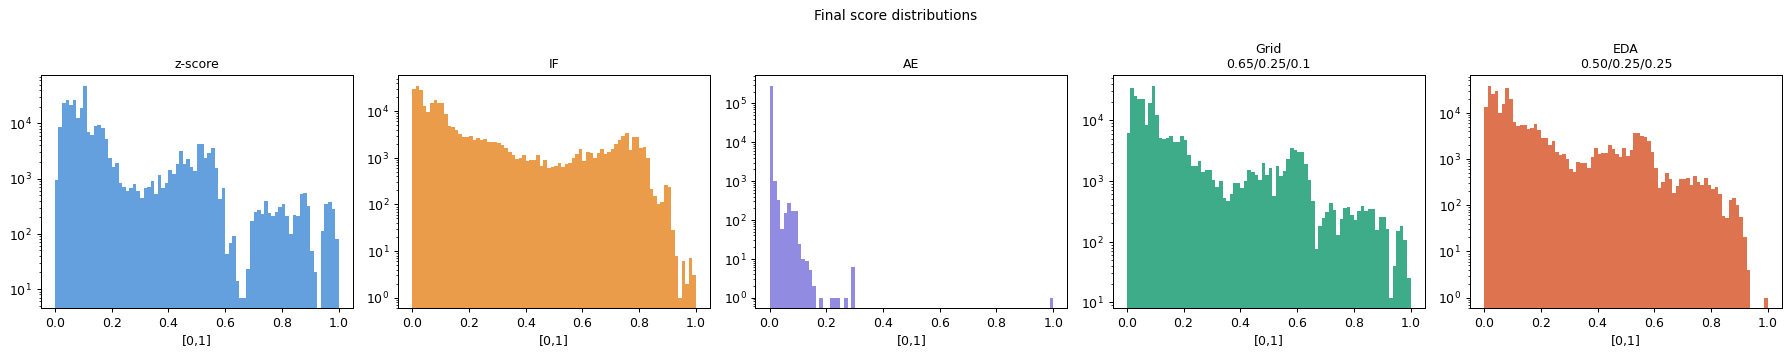

In [42]:
# Version A: grid-searched weights
ensemble_grid = minmax_01(W_Z*z_sc + W_IF*if_sc + W_AE*ae_sc)

# Version B: EDA-justified weights
ensemble_eda  = minmax_01(0.50*z_sc + 0.25*if_sc + 0.25*ae_sc)

print(f'{"Detector/Ensemble":<35} {"> 0.5":>8} {"> 0.7":>8} {"> 0.9":>8}')
print('-'*60)
for label, sc in [
    ('z-score only',z_sc),
    ('Isolation Forest only',if_sc),
    ('Dense AE only', ae_sc),
    (f'Ensemble grid {W_Z}/{W_IF}/{W_AE}', ensemble_grid),
    ('Ensemble EDA 0.50/0.25/0.25', ensemble_eda),
]:
    print(f'{label:<35} {(sc>0.5).sum():>8,} {(sc>0.7).sum():>8,} {(sc>0.9).sum():>8,}')

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, score, label, color in zip(axes,
    [z_sc, if_sc, ae_sc, ensemble_grid, ensemble_eda],
    ['z-score', 'IF', 'AE', f'Grid\n{W_Z}/{W_IF}/{W_AE}', 'EDA\n0.50/0.25/0.25'],
    ['#4A90D9','#E88B2A','#7F77DD','#1D9E75','#D85A30']):
    ax.hist(score, bins=80, color=color, alpha=0.85, edgecolor='none')
    ax.set_yscale('log'); ax.set_title(label, fontsize=10); ax.set_xlabel('[0,1]')
plt.suptitle('Final score distributions', fontsize=11)
plt.tight_layout(); plt.show()


In [43]:
def save_sub(scores, fname):
    sub = pd.DataFrame({'ID': test['ID'].values, 'TARGET': scores})
    sub.to_csv(OUTPUT_DIR + fname, index=False)
    print(f'Saved: {fname:<50}  (>0.9: {(scores>0.9).sum():,}  max: {scores.max():.4f})')

save_sub(ensemble_grid, f'submission_ensemble_grid_{W_Z}_{W_IF}_{W_AE}.csv')
save_sub(ensemble_eda,  'submission_ensemble_eda_0.50_0.25_0.25.csv')

Saved: submission_ensemble_grid_0.65_0.25_0.1.csv          (>0.9: 934  max: 1.0000)
Saved: submission_ensemble_eda_0.50_0.25_0.25.csv          (>0.9: 81  max: 1.0000)


----

# EXTRA

In this final part, we combine the three anomaly detectors into one final anomaly score. This follows the same general idea as bagging and ensemble learning from Chapter 7. In bagging, instead of relying on only one model, we average the outputs of several models:

$$\hat{g}_{\text{bag}}(x) = \frac{1}{M} \sum_{k=1}^{M} \hat{g}_k(x)$$

The reason this helps is explained by the Krogh–Vedelsby decomposition:

$$E = \bar{E} - \bar{A}$$

where $E$ is the ensemble error, $\bar{E}$ is the average error of the individual models, and $\bar{A}$ is the ambiguity, or diversity, between the models. The important intuition is that an ensemble works best when the models are not all making the exact same mistakes. If the individual detectors capture different types of anomalies, then combining them should give a more stable and complete anomaly score.

In our case, we have three different anomaly detectors: the statistical z-score detector, the Isolation Forest, and the Dense Autoencoder. Each one gives a normalized score between 0 and 1. We combine them using a weighted linear ensemble:

$$\text{score}_{\text{final}}(i)=w_z \cdot \text{score}_z(i)+w_{\text{IF}} \cdot \text{score}_{\text{IF}}(i)+w_{\text{AE}} \cdot \text{score}_{\text{AE}}(i)$$

with the constraint that the weights must sum to 1:

$$
w_z + w_{\text{IF}} + w_{\text{AE}} = 1
$$

and each weight must be non-negative:

$$
w_z, w_{\text{IF}}, w_{\text{AE}} \geq 0
$$

Initially, based on our EDA, we used the following weights:

$$
w_z = 0.50, 
\qquad
w_{\text{IF}} = 0.25,
\qquad
w_{\text{AE}} = 0.25
$$

The z-score receives the highest weight because our EDA showed that it had the strongest direct signal. In particular, burst orders were strongly associated with abnormal returns, with the burst return ratio being around $175\times$ larger than normal single-order behavior. We also observed that some test values went far beyond the training range, reaching about $11.6\times$ the training maximum. This made the z-score detector especially useful because it directly captures extreme feature-level deviations. However, we still included Isolation Forest and the Autoencoder because they capture different types of anomalies. Isolation Forest adds a multivariate outlier signal, while the Dense Autoencoder adds a nonlinear reconstruction-error signal.

To make the weight choice more rigorous, we also performed a grid search over possible ensemble weights. Since we did not have fraud labels during development, we could not directly optimize AUROC. Instead, we used a proxy metric based on score separation. The idea is that a useful anomaly score should push suspicious rows toward the top of the score distribution while keeping normal-looking rows closer to the middle. So we measured the difference between the 99th percentile and the 50th percentile of the combined score:

$$
\Delta(w)
=
P_{99}\left[\text{score}_{\text{final}}\right]
-
P_{50}\left[\text{score}_{\text{final}}\right]
$$

A larger value of $\Delta(w)$ means that the top anomaly candidates are more clearly separated from the median row. This is not the same as AUROC because we do not use true labels, but it is a reasonable unsupervised proxy because AUROC also depends on whether anomalous rows are ranked above normal rows.

In the grid search, we tested different combinations of weights where the z-score weight ranged from $0.30$ to $0.65$, the Isolation Forest weight ranged from $0.10$ to $0.45$, and the Autoencoder weight was calculated as:

$$
w_{\text{AE}} = 1 - w_z - w_{\text{IF}}
$$

We also required the Autoencoder weight to stay between $0.10$ and $0.60$:

$$
0.10 \leq w_{\text{AE}} \leq 0.60
$$

This means no detector was allowed to disappear completely from the ensemble. Each model had to contribute at least meaningfully to the final score. For every valid weight combination, we computed the ensemble score:

$$
\text{combo}
=
w_z \cdot z_{\text{sc}}
+
w_{\text{IF}} \cdot \text{if}_{\text{sc}}
+
w_{\text{AE}} \cdot \text{ae}_{\text{sc}}
$$

Then we min-max normalized it to the range $[0,1]$:

$$
\text{combo}_{\text{norm}}
=
\frac{\text{combo} - \min(\text{combo})}
{\max(\text{combo}) - \min(\text{combo}) + 10^{-9}}
$$

After that, we calculated the separation score:

$$
\text{separation}
=
P_{99}(\text{combo}_{\text{norm}})
-
P_{50}(\text{combo}_{\text{norm}})
$$

The code stores every valid weight combination and its separation value in a results dataframe, then sorts the results from highest to lowest separation. The best combination is selected as the one with the highest separation score:

$$
(W_Z, W_{\text{IF}}, W_{\text{AE}})
=
\arg\max_w \Delta(w)
$$

This gives us a data-driven way to check whether the EDA-based weights make sense. If the best grid-searched weights are close to the original $0.50/0.25/0.25$ split, then it validates the EDA reasoning. If they differ significantly, then the grid search may have found a better combination based on the separation proxy.

After selecting the grid-search weights, we created two final ensemble versions. Version A uses the best weights found by the grid search:

$$
\text{ensemble}_{\text{grid}}
=
W_Z \cdot z_{\text{sc}}
+
W_{\text{IF}} \cdot \text{if}_{\text{sc}}
+
W_{\text{AE}} \cdot \text{ae}_{\text{sc}}
$$

Version B uses the original EDA-justified weights:

$$
\text{ensemble}_{\text{EDA}}
=
0.50 \cdot z_{\text{sc}}
+
0.25 \cdot \text{if}_{\text{sc}}
+
0.25 \cdot \text{ae}_{\text{sc}}
$$

Both ensemble scores are then min-max normalized to $[0,1]$ before submission:

$$
\text{score}_{\text{norm}}(i)
=
\frac{\text{score}(i) - \min_j \text{score}(j)}
{\max_j \text{score}(j) - \min_j \text{score}(j) + 10^{-9}}
$$

Finally, we compare the individual detectors and the two ensemble versions by counting how many observations receive high scores above $0.5$, $0.7$, and $0.9$. This helps us understand how selective or aggressive each score is. We also plot the score distributions for the z-score detector, Isolation Forest, Dense Autoencoder, grid-search ensemble, and EDA-weighted ensemble. The histogram plots show whether each method produces a smooth score distribution or whether it concentrates many observations near very low or very high anomaly scores.

The reason this ensemble is useful is that each detector captures a different kind of anomaly. The z-score detector captures extreme individual-feature values, especially when:

$$
|z_{i,f,s}| \gg 1
$$

Isolation Forest captures multivariate outliers in the full feature space by identifying observations that are isolated quickly:

$$
E[h(x)] \ll c(n)
$$

The Dense Autoencoder captures nonlinear patterns that are hard to reconstruct, which leads to a high reconstruction error:

$$
e_i \gg 0
$$

Because these three methods focus on different anomaly mechanisms, the ensemble has useful diversity. This connects back to the Krogh–Vedelsby result:

$$
E = \bar{E} - \bar{A}
$$

The ambiguity term $\bar{A}$ is valuable here because the detectors are not identical. They each identify different suspicious regions of the data. Therefore, combining them should produce a more stable and reliable final anomaly score than relying on only one detector.

## Section 7 Detector 3: Dense Autoencoder
### What it does:  

A neural network trained to compress 37 features -> 8 -> reconstruct back to 37.

```
Input (37)  ->  Dense(20, ReLU)  -> Dense(8, ReLU)   <- encoder
            →  Dense(20, ReLU)    Output (37)        <- decoder
```

**The autoencoder trick**: we call `model.fit(X, X)` — the input IS the target.
The bottleneck (8 units) forces the network to learn a compressed representation
of what normal data looks like. After training:
- Normal rows reconstruct accurately → low error → low anomaly score
- Fraud rows have patterns the model never learned → bad reconstruction → high score

**Anomaly score** = Mean Squared Error between original and reconstructed values.

### Why this adds value on top of z-score and IF
The autoencoder learns **non-linear interactions** between features. z-score
treats features independently. IF captures linear-ish multivariate outliers.
The AE captures deeper patterns - for instance, a row where the combination of
TradeBidSize, CancelledBidSize, and ReturnBid1 has a joint relationship that
never appeared in 1.54M normal rows.


In this part, we use a dense autoencoder to detect anomalies based on reconstruction error. The idea comes from Chapter 11, where we first studied a simple autoencoder with a $2 \to 1 \to 2$ architecture. In that example, the model takes two input features, compresses them into one hidden representation, and then tries to reconstruct the original two features. The forward pass was written as:

$$
x_i = f_{1,i} \cdot w_1 + f_{2,i} \cdot w_2 + b_1
$$

$$
y_i = \text{ReLU}(x_i) = \max(0, x_i)
$$

$$
\hat{f}_{1,i} = y_i \cdot w_3 + b_2,
\qquad
\hat{f}_{2,i} = y_i \cdot w_4 + b_3
$$

The model is trained by comparing the reconstructed output to the original input. This is why, in code, we train the autoencoder using `model.fit(X, X)`: the input and the target are the same. The loss function is the mean squared reconstruction error:

$$
L = \frac{1}{2} \sum_i \sum_j (\hat{f}_{j,i} - f_{j,i})^2
$$

Our model uses the same logic, but with a larger architecture:

$$
37 \to 20 \to 8 \to 20 \to 37
$$

This means that the model starts with 37 input features, compresses them through hidden layers of 20 and 8 units, and then expands them back to 37 reconstructed features. For a general layer $l$, the model first applies a linear transformation using a weight matrix $W^{(l)}$ and bias vector $\mathbf{b}^{(l)}$:

$$
\mathbf{z}^{(l)} = W^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}
$$

Then it applies the ReLU activation function:

$$
\mathbf{a}^{(l)} = \text{ReLU}(\mathbf{z}^{(l)})
= \max(\mathbf{0}, \mathbf{z}^{(l)})
$$

where $\mathbf{a}^{(0)} = \mathbf{x}$ is the original input row. The final output layer uses a linear activation, meaning it does not apply ReLU at the end. This is the same idea as in Chapter 11, where the output layer directly reconstructs the original feature values:

$$
\hat{\mathbf{x}} = W^{(4)} \mathbf{a}^{(3)} + \mathbf{b}^{(4)}
$$

The most important part of the architecture is the bottleneck layer, which has only 8 units. This layer forces the model to compress the original 37 features into a smaller representation:

$$
\text{enc}: \mathbb{R}^{37} \to \mathbb{R}^{8}
$$

Then the decoder maps this compressed representation back to the original feature space:

$$
\text{dec}: \mathbb{R}^{8} \to \mathbb{R}^{37}
$$

So the full autoencoder can be written as:

$$
\hat{\mathbf{x}} = \text{dec}(\text{enc}(\mathbf{x}))
$$

This bottleneck is important because it prevents the model from simply memorizing every row. Instead, it has to learn the main structure of the normal data. Since the model is trained only on normal samples, it should become good at reconstructing normal rows, but worse at reconstructing unusual or fraudulent rows.

The training loss over $N$ normal samples and $F = 37$ features is:

$$
L = \frac{1}{N} \sum_{i=1}^{N}
\frac{1}{F} \sum_{f=1}^{F}
(\hat{x}_{i,f} - x_{i,f})^2
$$

This is still the same MSE idea from Chapter 11, but generalized to many samples and many features. The model is trying to make the reconstructed value $\hat{x}_{i,f}$ as close as possible to the original value $x_{i,f}$ for every feature in every normal training row.

Training is done using backpropagation. The main idea is that the model calculates how much each weight and bias contributed to the reconstruction error, then updates them in the direction that reduces the loss. For the output layer, the gradients are:

$$
\frac{\partial L}{\partial W^{(4)}} =
\frac{1}{N}(\hat{X} - X)^\top \mathbf{a}^{(3)}
$$

$$
\frac{\partial L}{\partial \mathbf{b}^{(4)}} =
\frac{1}{N} \sum_i (\hat{\mathbf{x}}_i - \mathbf{x}_i)
$$

For each hidden layer $l$, the error is passed backward using the chain rule:

$$
\boldsymbol{\delta}^{(l)}
=
\left(W^{(l+1)}\right)^\top
\boldsymbol{\delta}^{(l+1)}
\odot
\text{ReLU}'(\mathbf{z}^{(l)})
$$

where

$$
\text{ReLU}'(z) = \mathbf{1}[z > 0]
$$

and $\odot$ means element-wise multiplication. The gradients for the weights and biases in layer $l$ are:

$$
\frac{\partial L}{\partial W^{(l)}} =
\frac{1}{N}
\left(\boldsymbol{\delta}^{(l)}\right)^\top
\mathbf{a}^{(l-1)}
$$

$$
\frac{\partial L}{\partial \mathbf{b}^{(l)}} =
\frac{1}{N} \sum_i \boldsymbol{\delta}_i^{(l)}
$$

Then the weights are updated using gradient descent with learning rate $\varepsilon$:

$$
W^{(l)} \leftarrow
W^{(l)}
-
\varepsilon \cdot
\frac{\partial L}{\partial W^{(l)}}
$$

After the autoencoder is trained, we use reconstruction error as the anomaly score. For each test row $i$, the reconstruction error is:

$$
e_i =
\frac{1}{F}
\sum_{f=1}^{F}
(\hat{x}_{i,f} - x_{i,f})^2
$$

This is the same MSE formula used during training, but now it is evaluated on a test row. If the row is normal, the model should reconstruct it well, so $e_i$ should be small. If the row is anomalous or fraudulent, the model may not reconstruct it well because that type of pattern was not learned during training, so $e_i$ should be larger.

Finally, the reconstruction errors are min-max normalized to the range $[0,1]$:

$$
\text{score}_{\text{AE}}(i) =
\frac{e_i - \min_j e_j}
{\max_j e_j - \min_j e_j + \varepsilon}
$$

The small $\varepsilon$ is added to avoid division by zero. After normalization, a higher $\text{score}_{\text{AE}}(i)$ means the row has a larger reconstruction error and is therefore more likely to be anomalous.
